<hr>

### [Supabase](https://supabase.com/) 

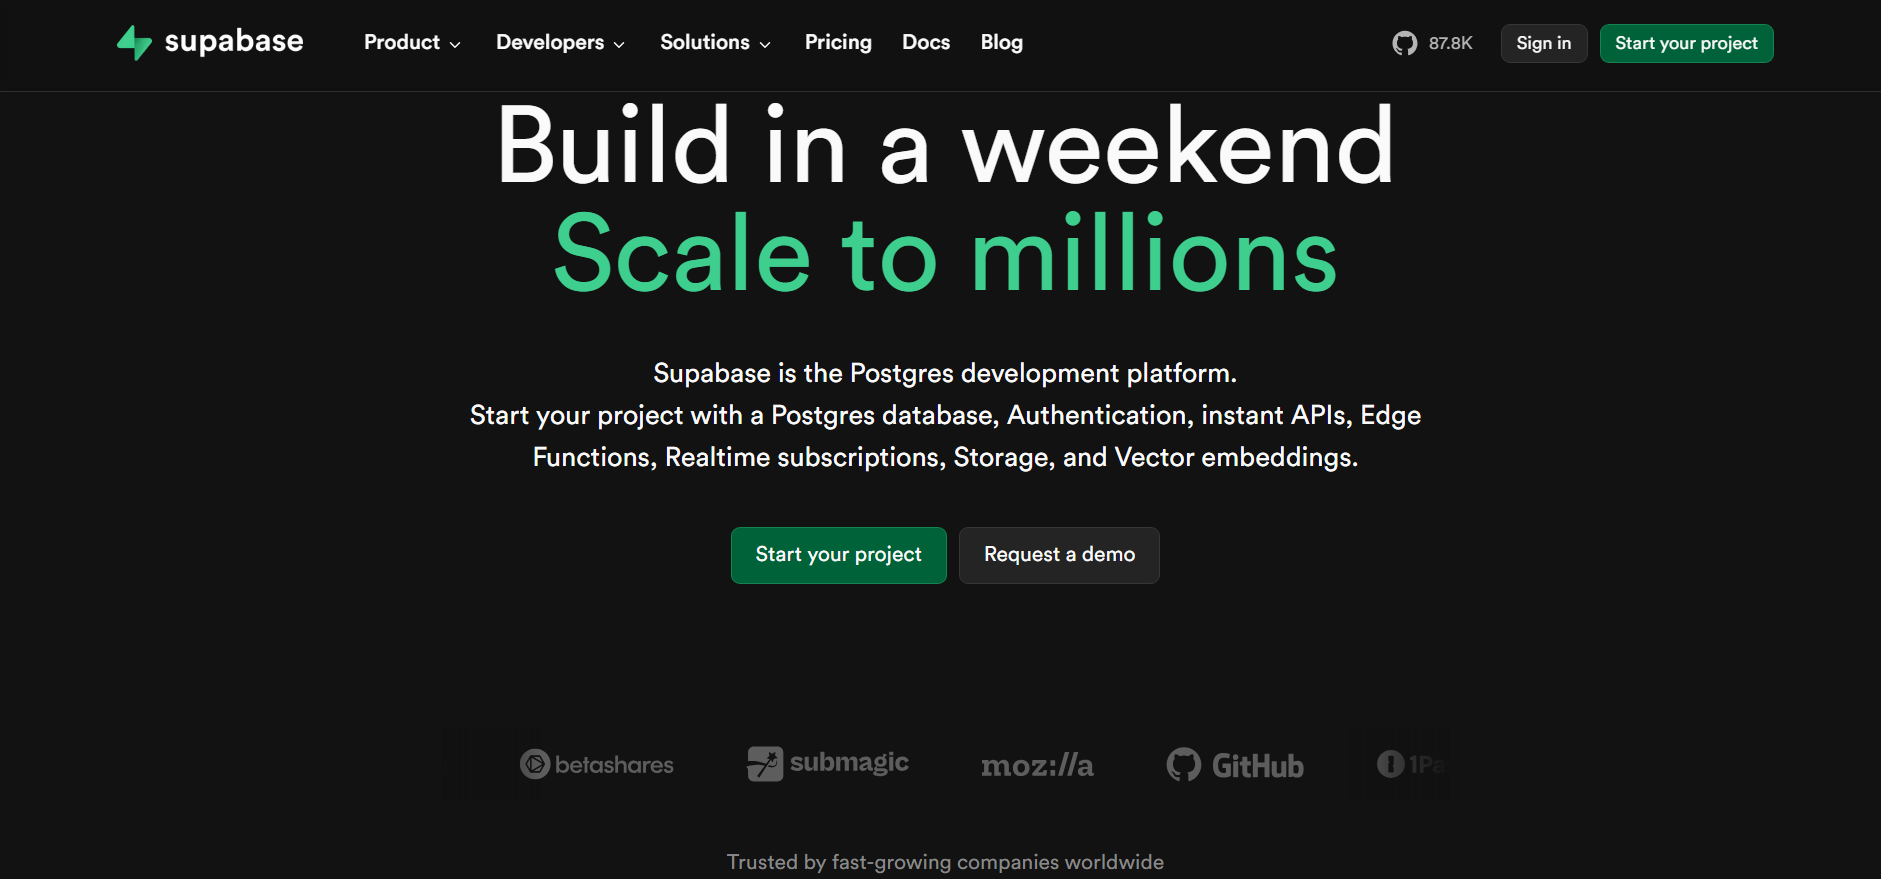 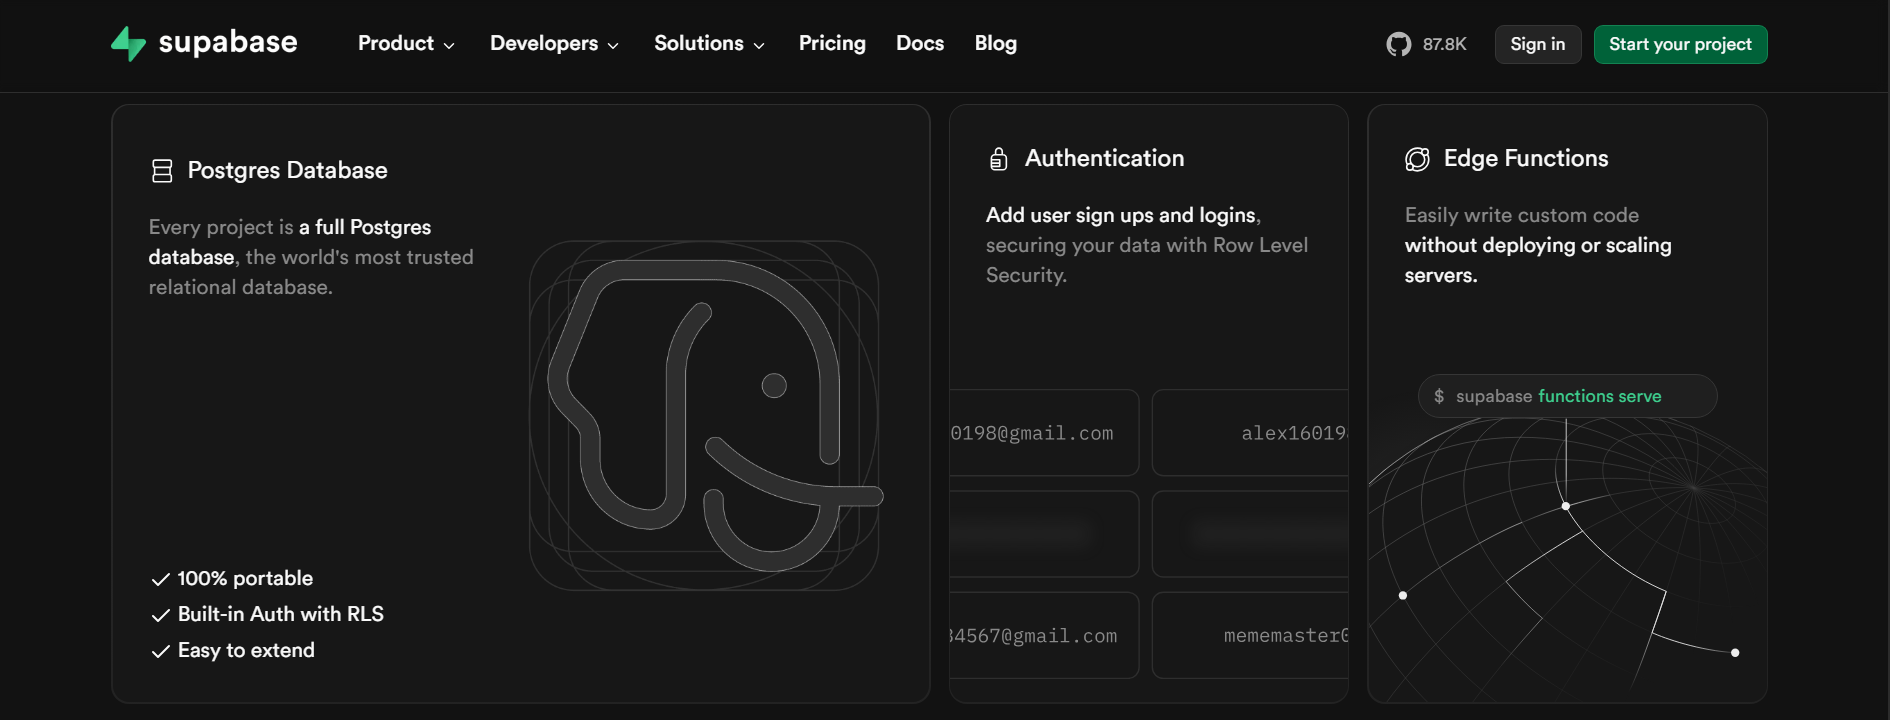
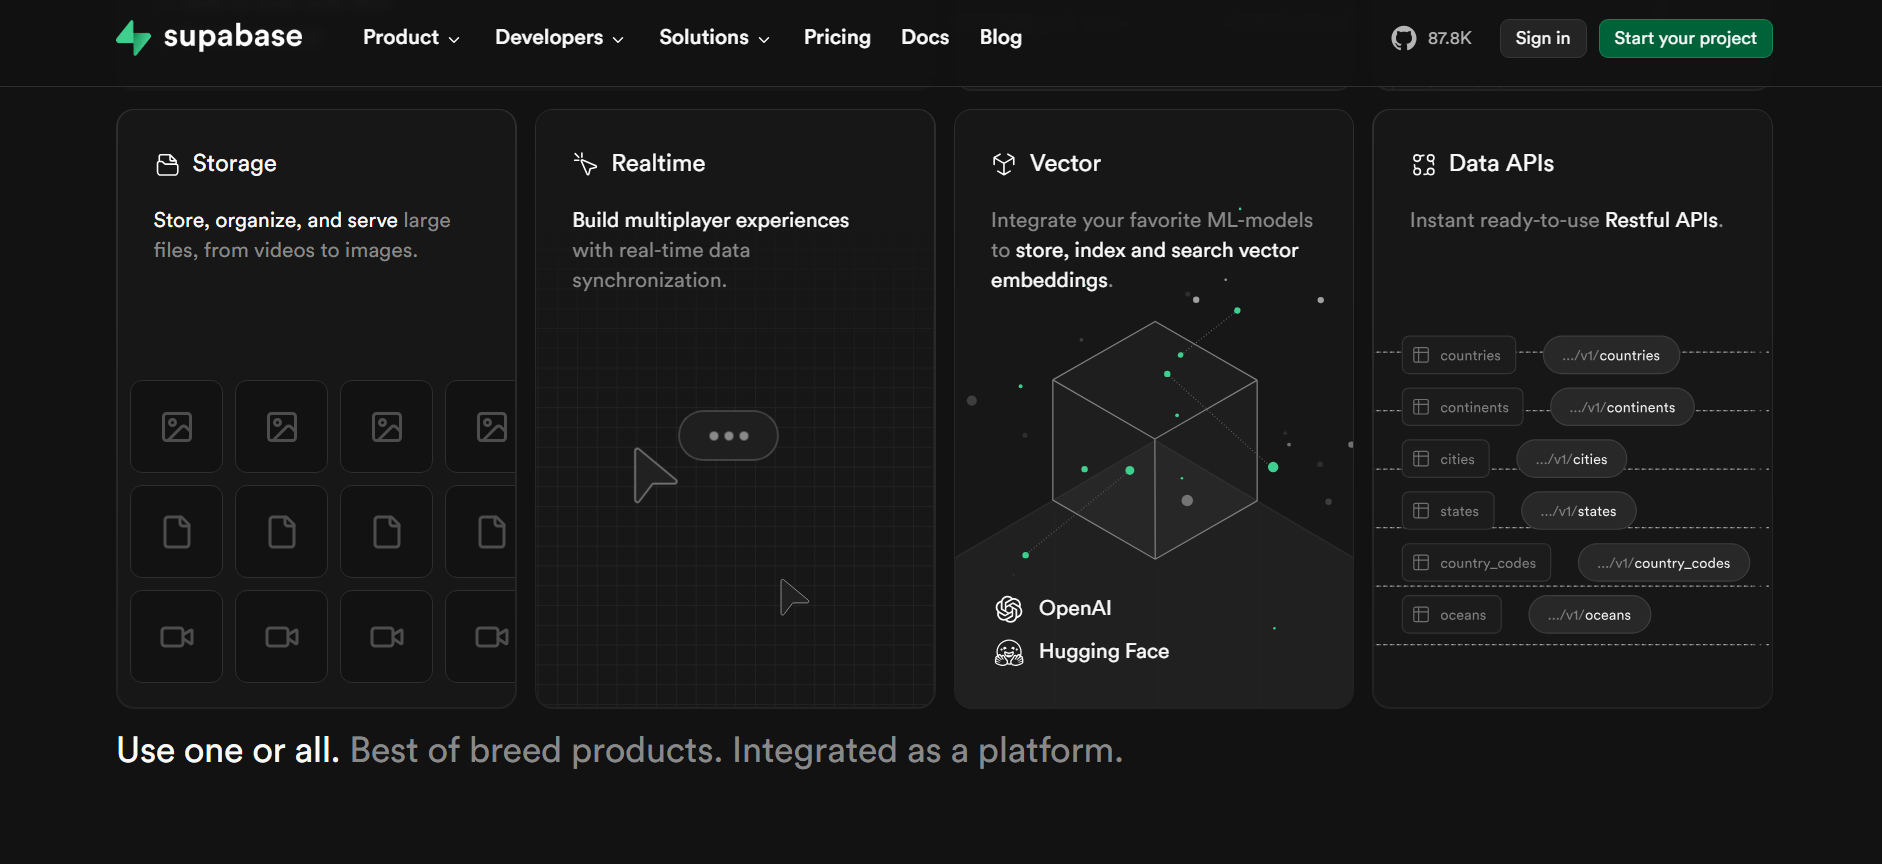 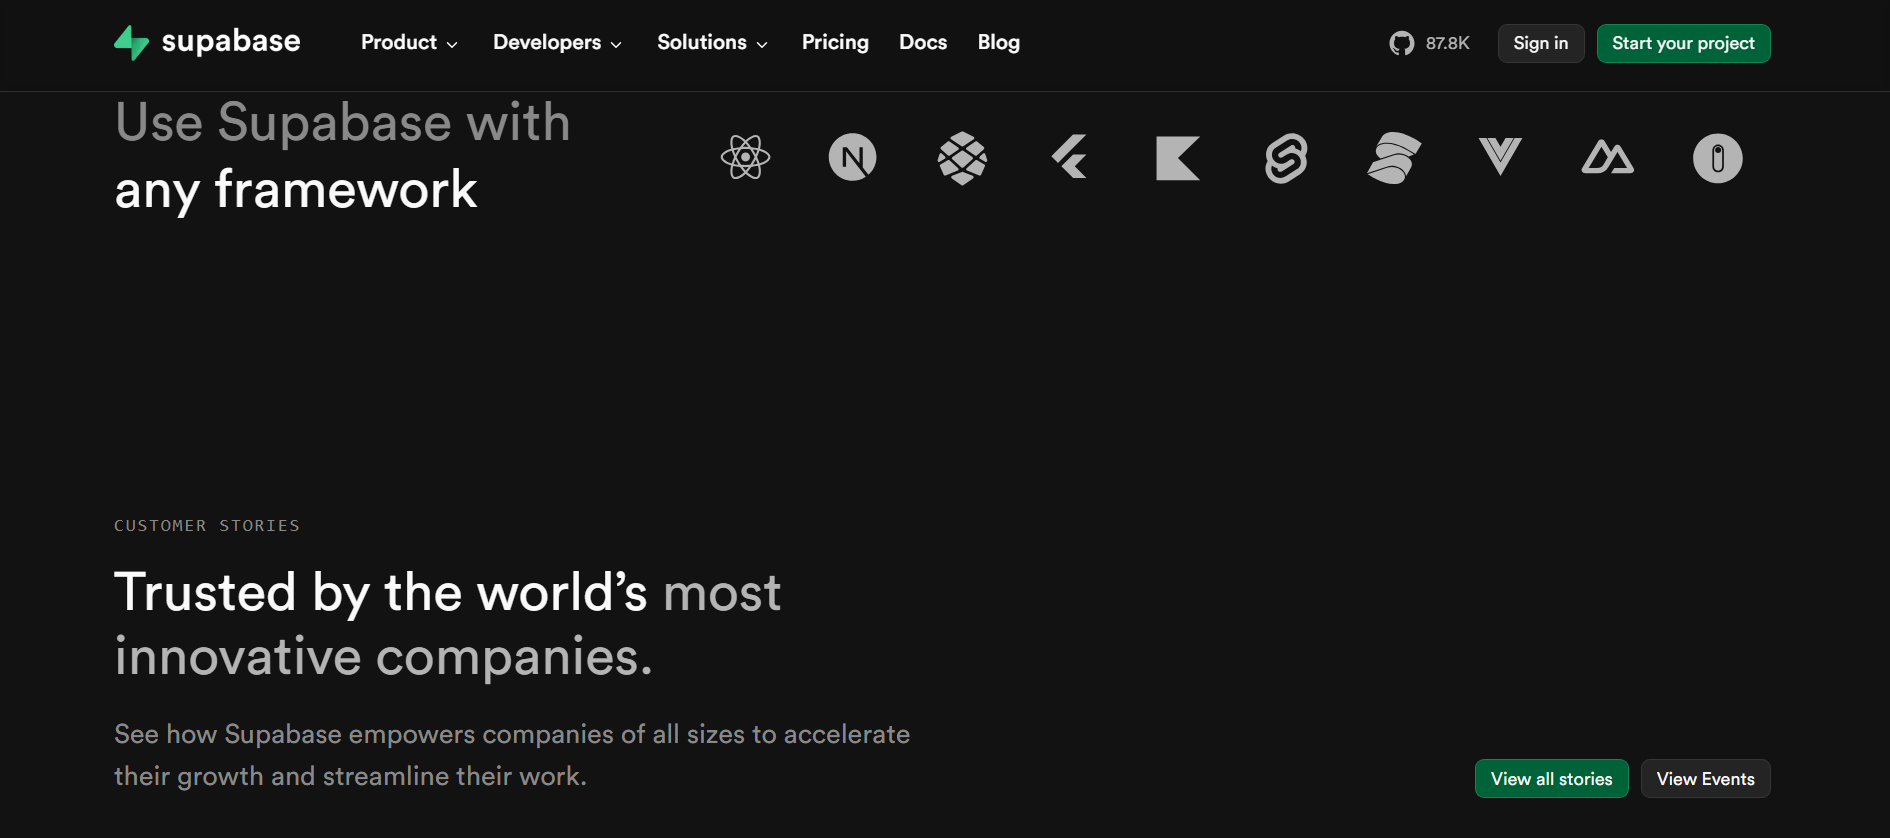 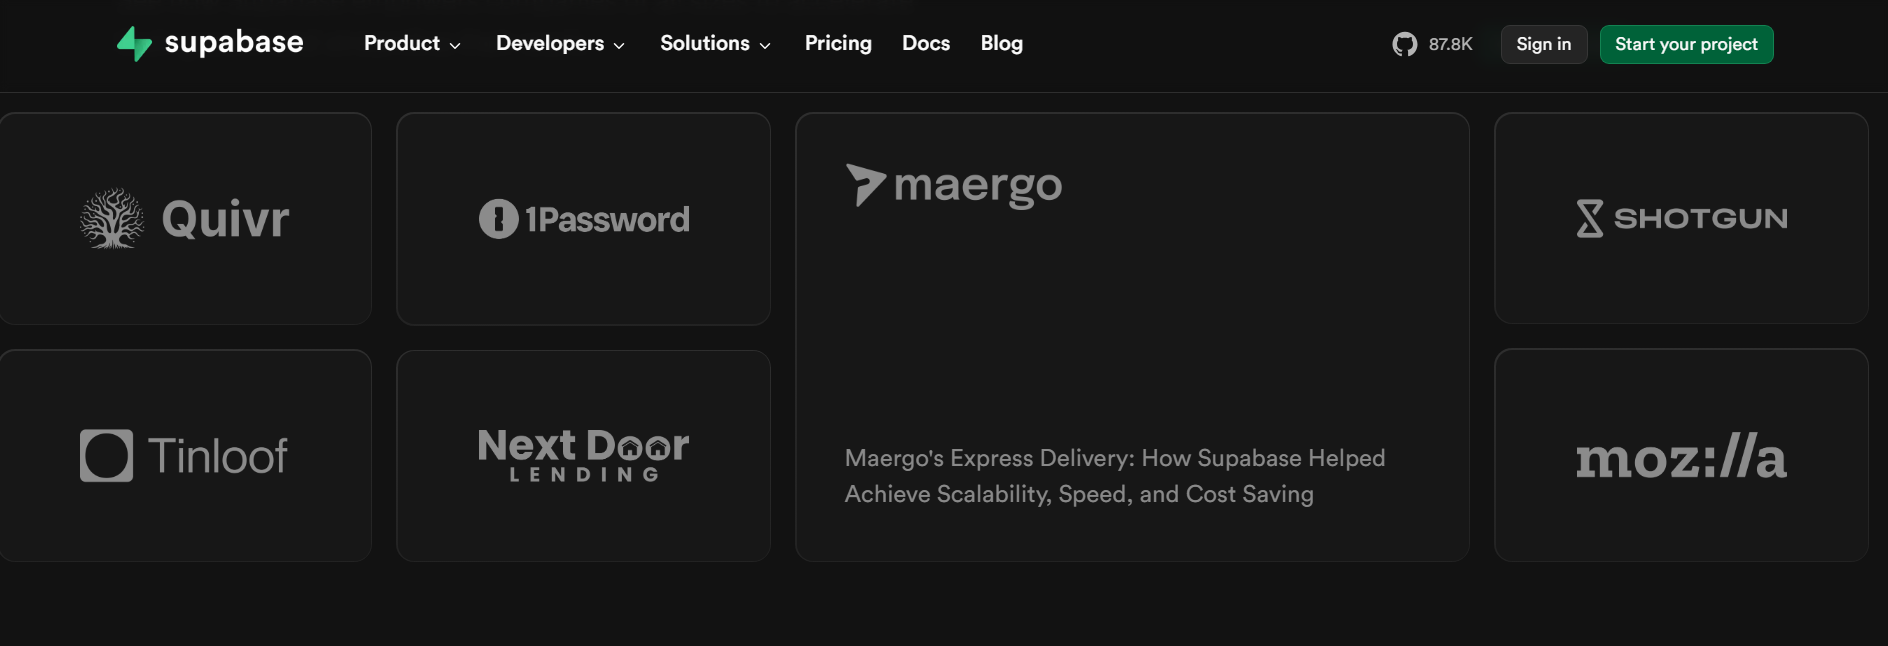
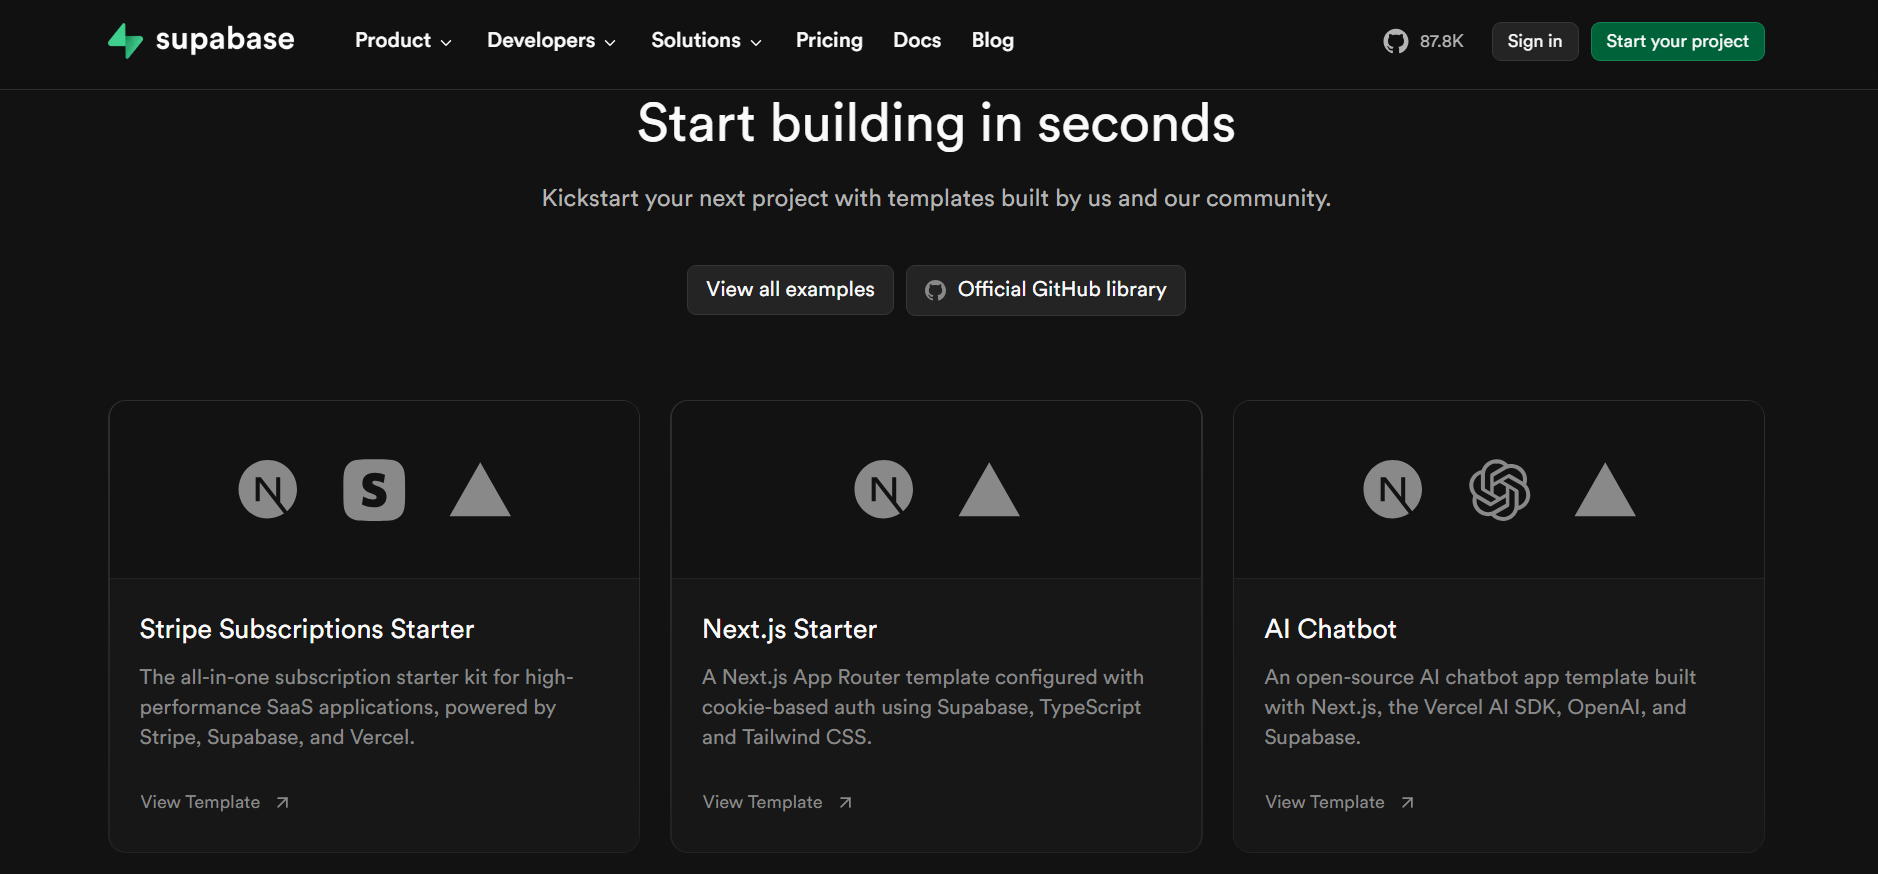 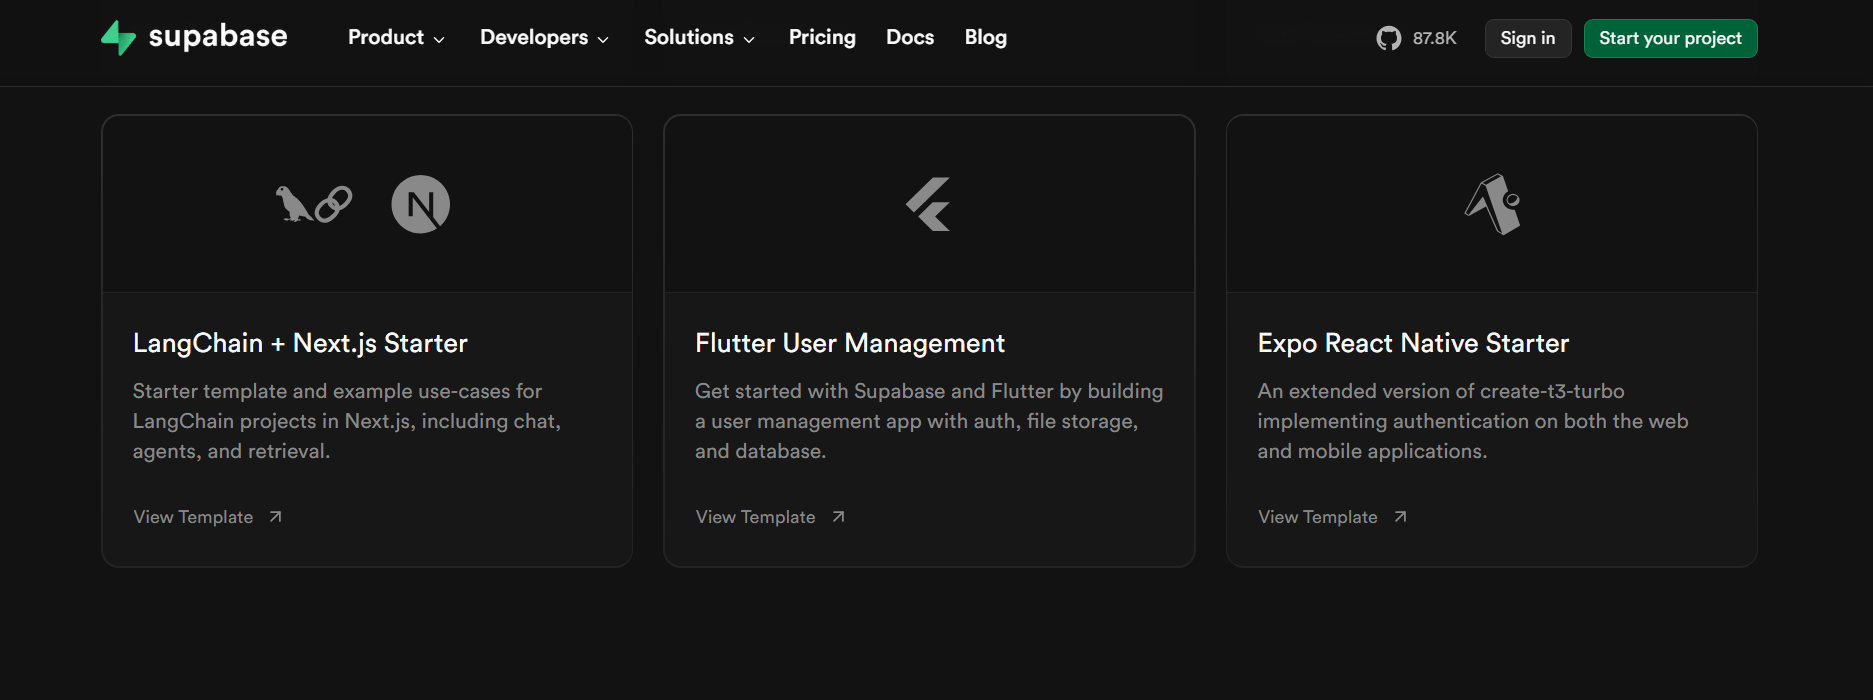 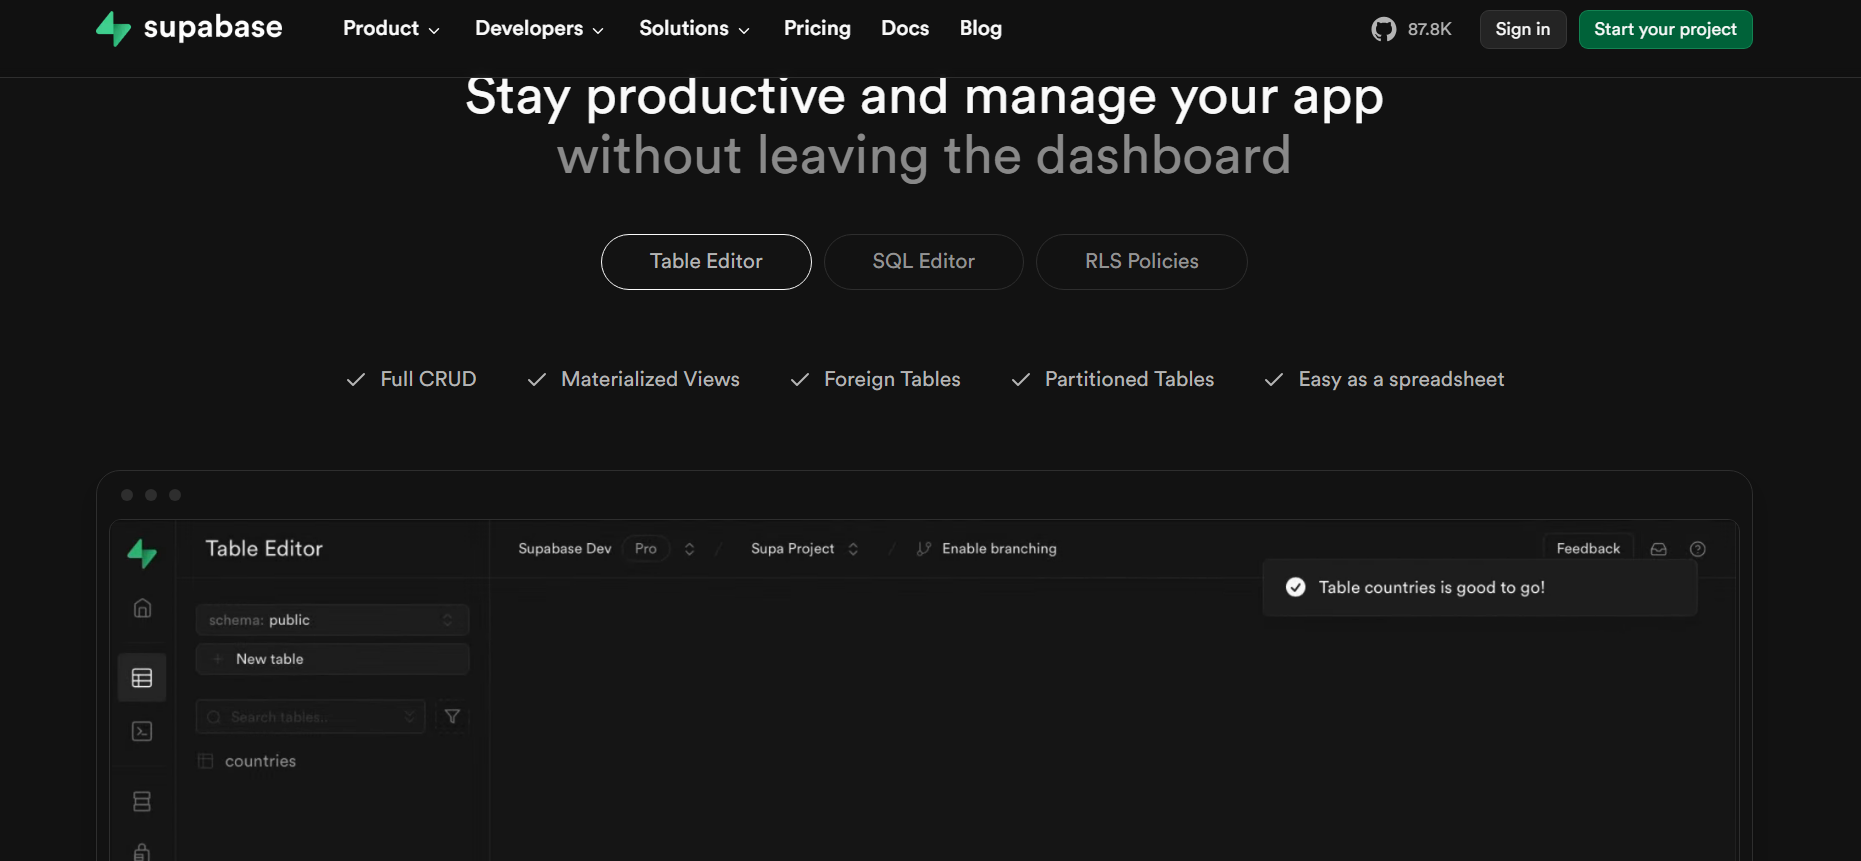
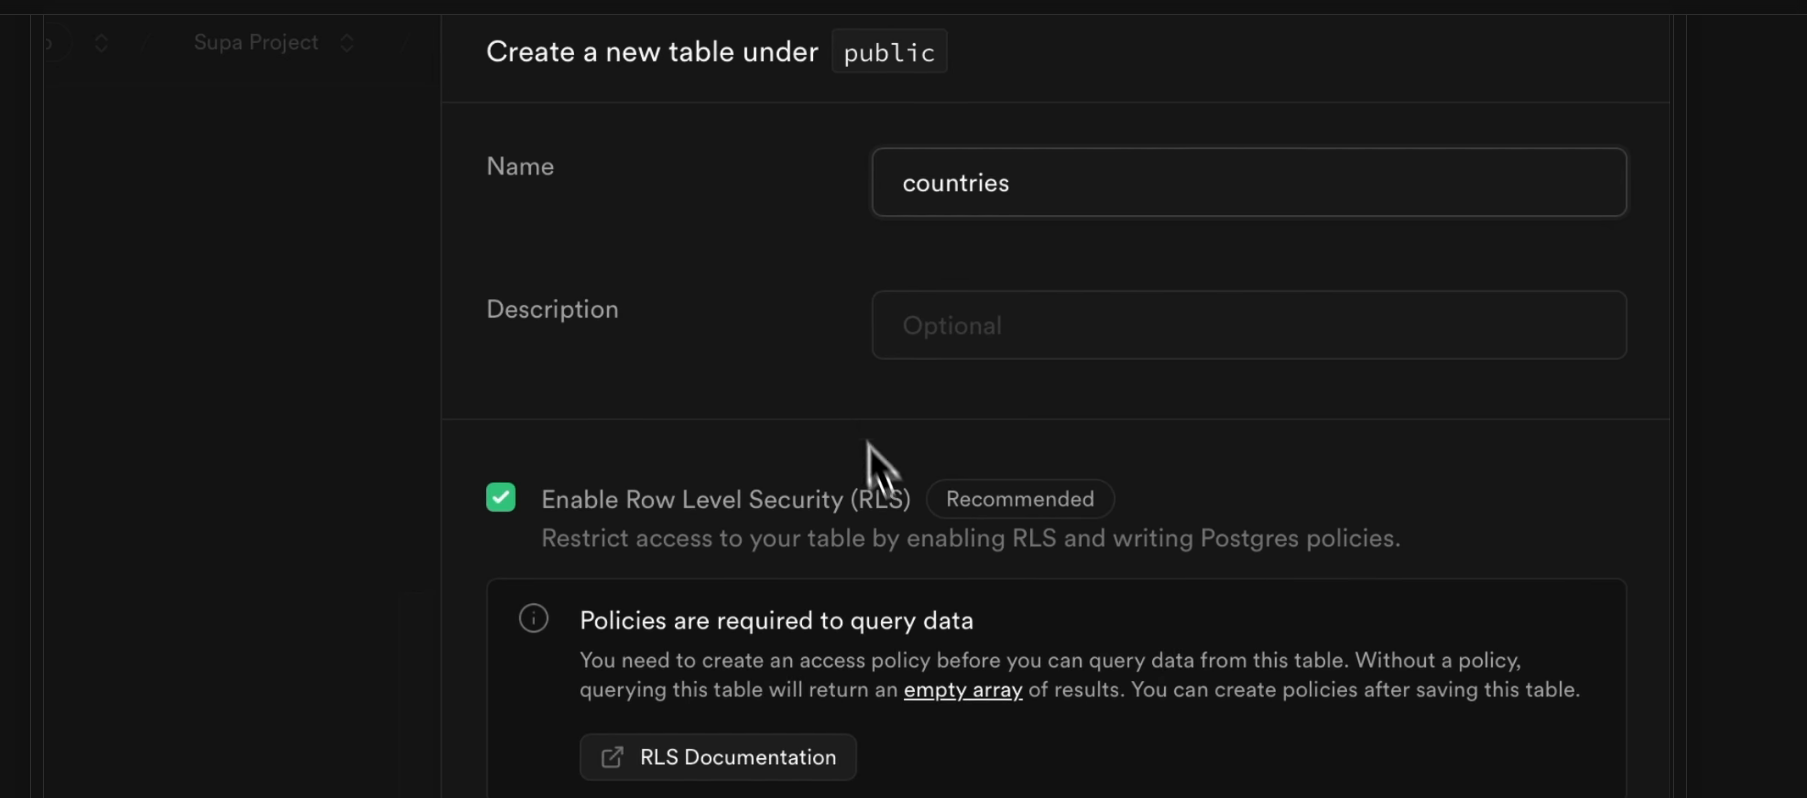

`Create New Account in Supabase`

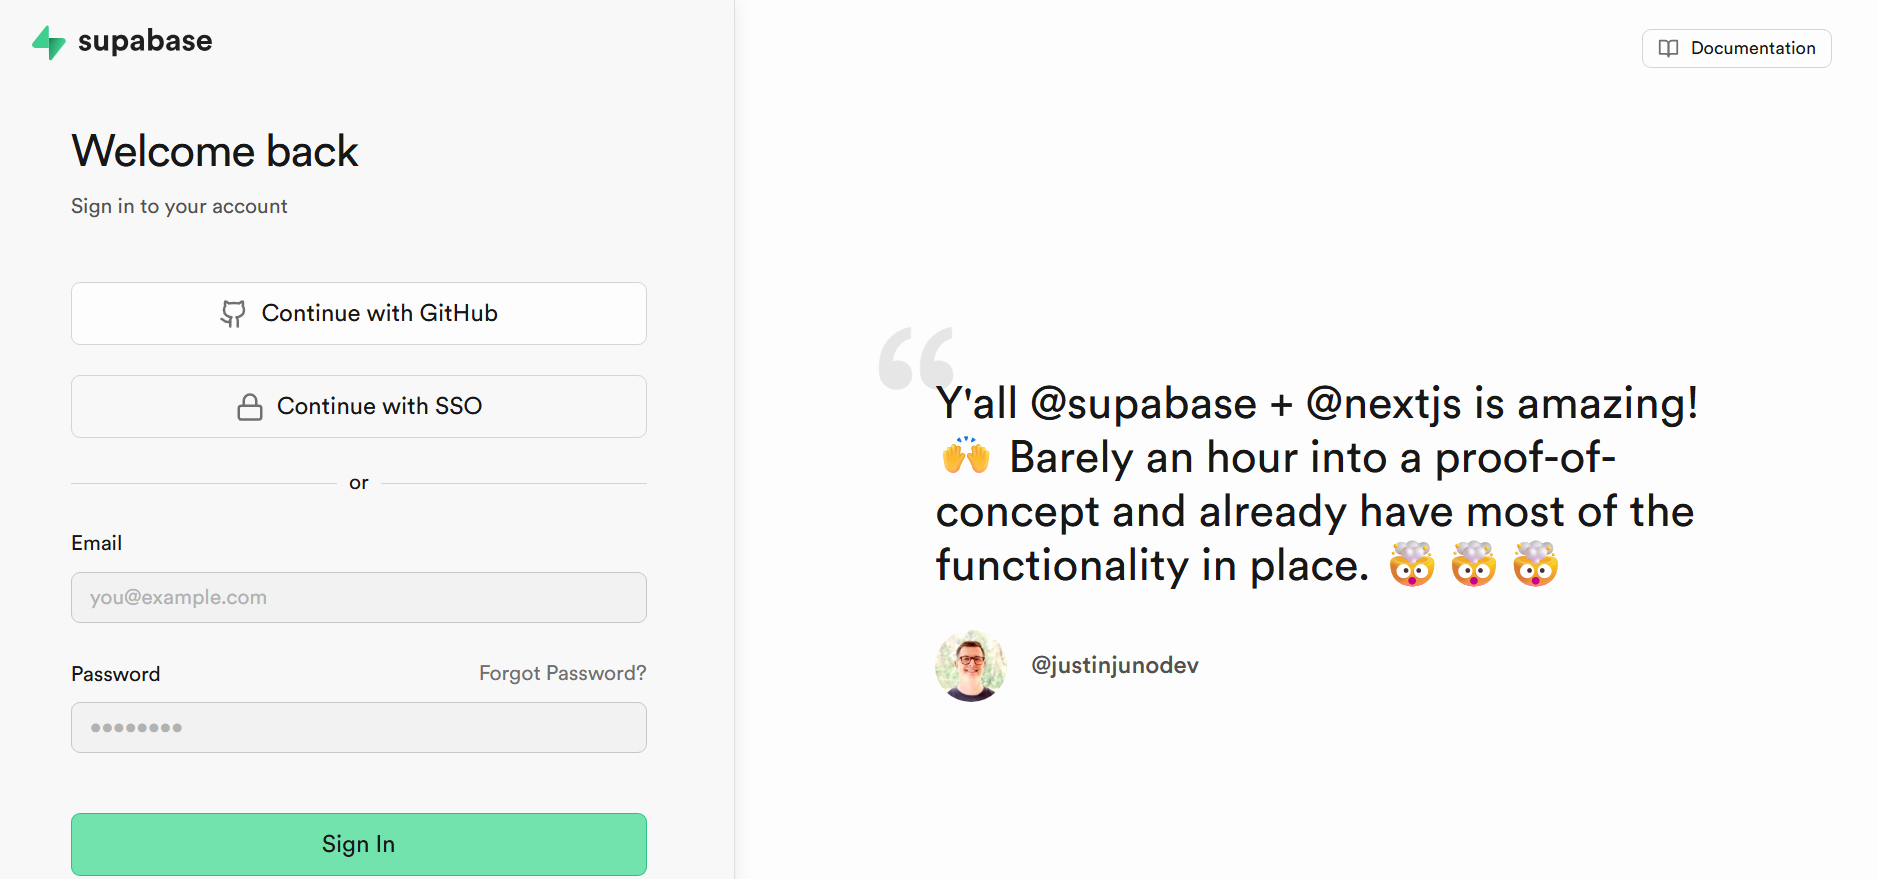 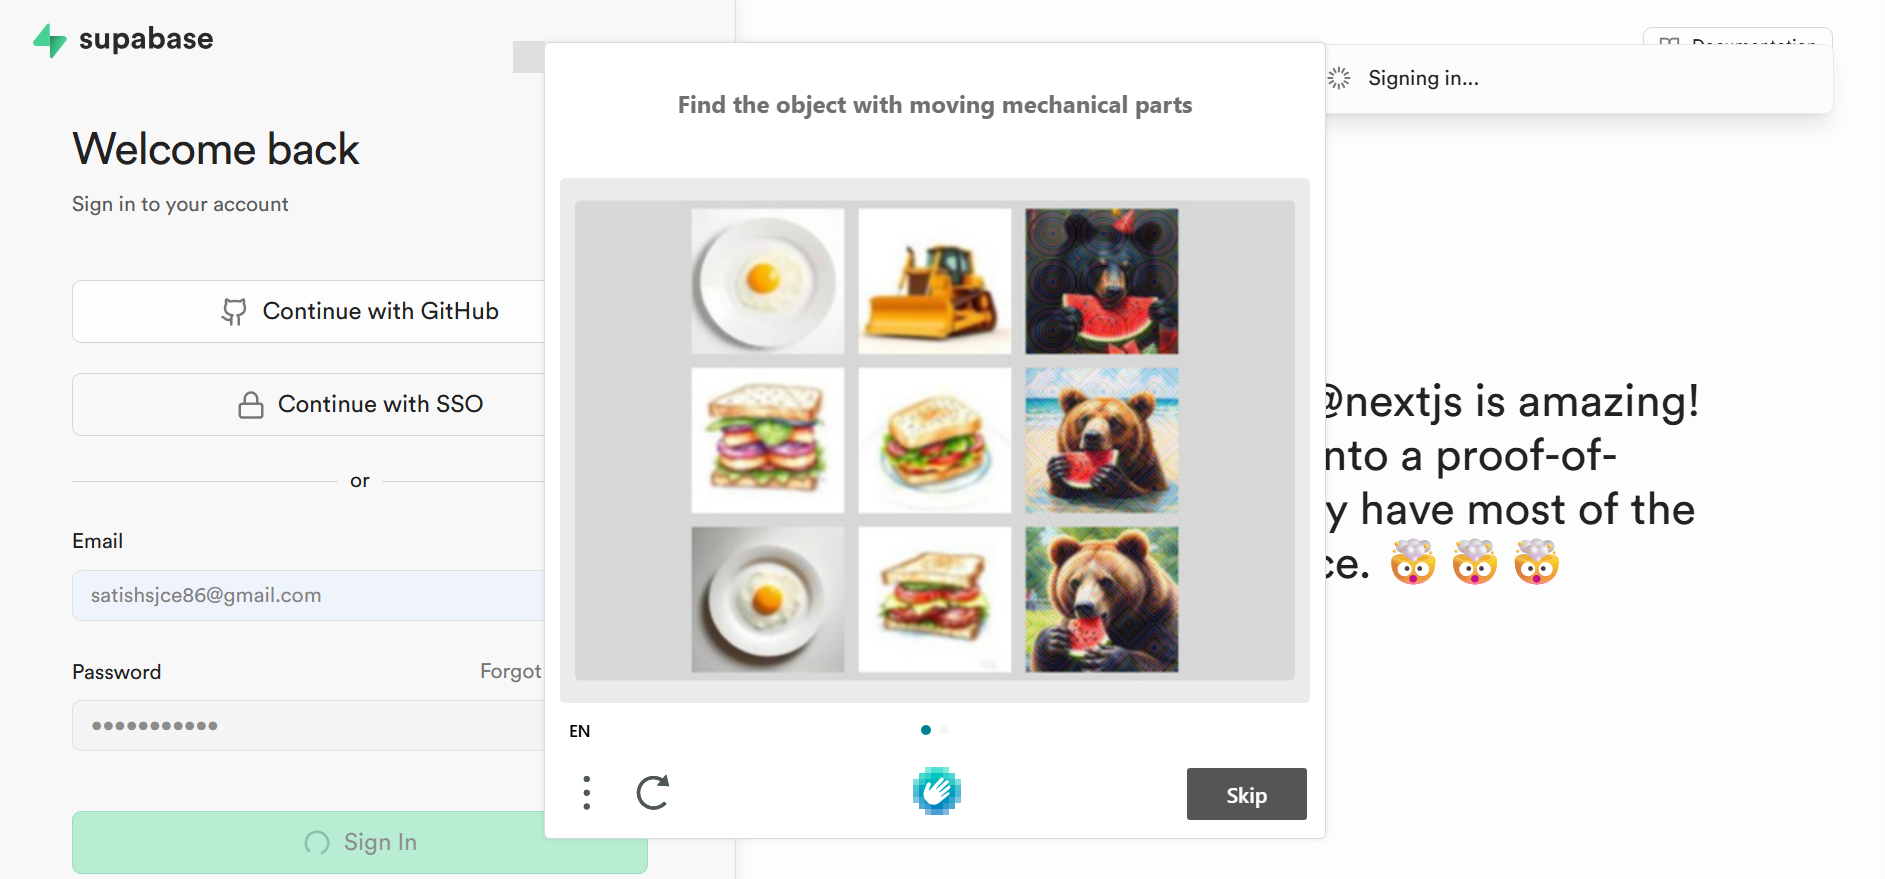 

`Create New Organization`

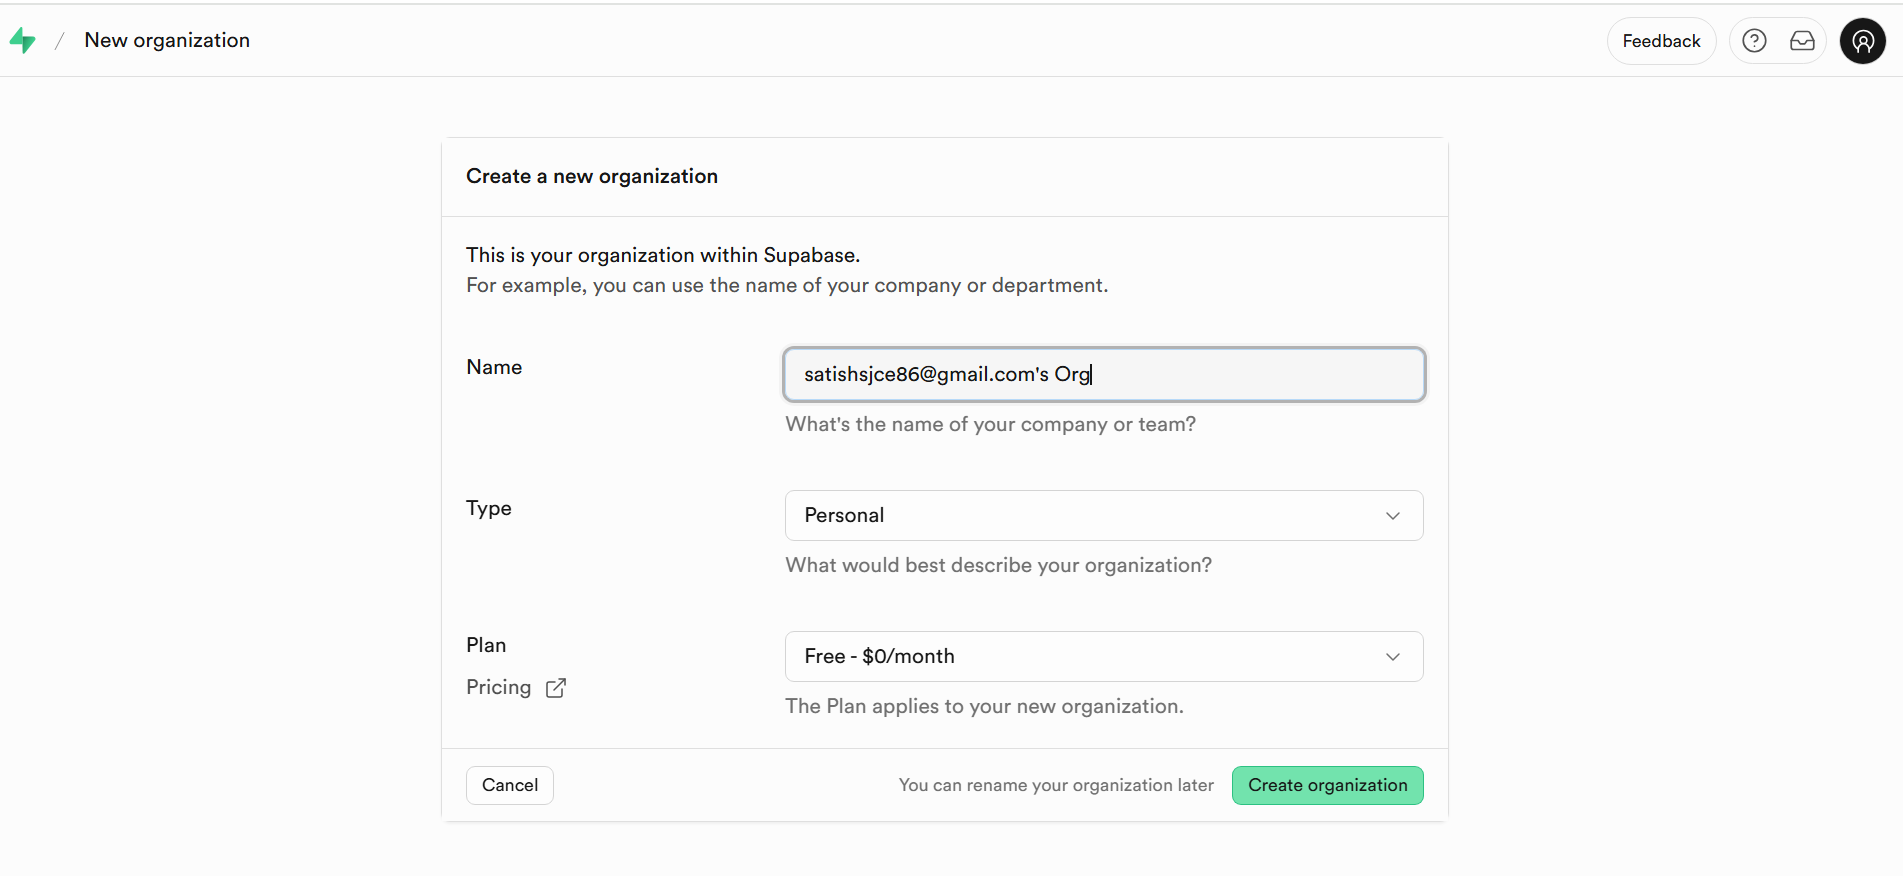 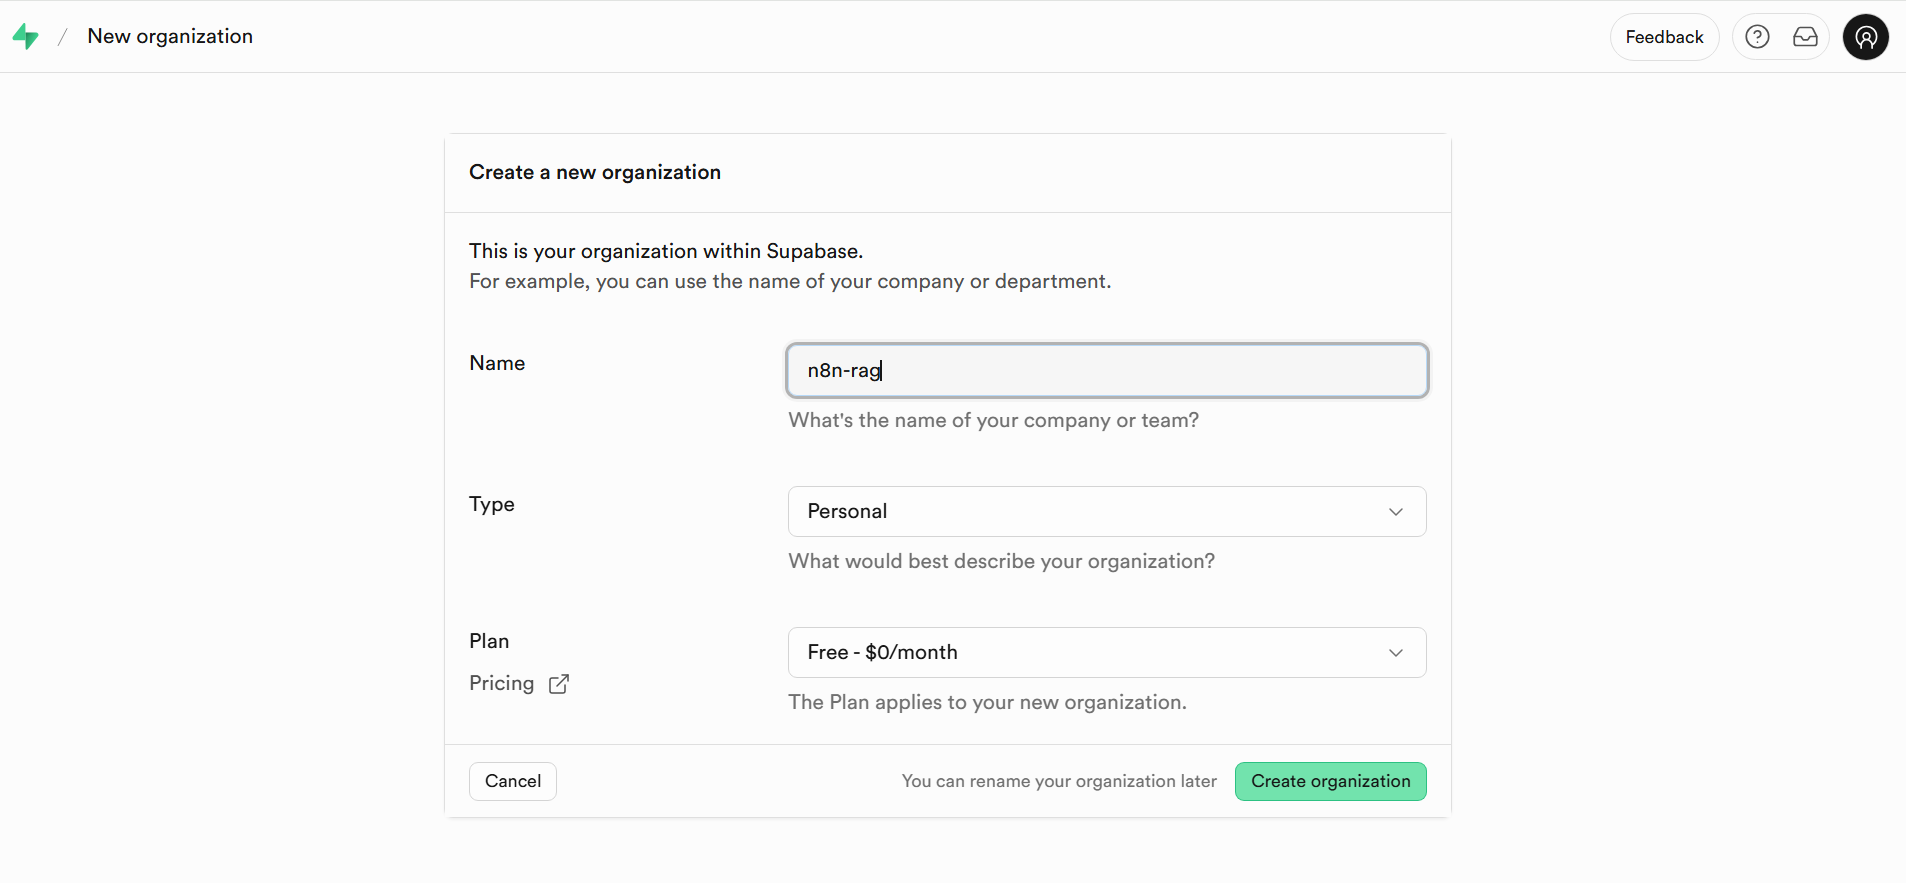

`Create New Project`

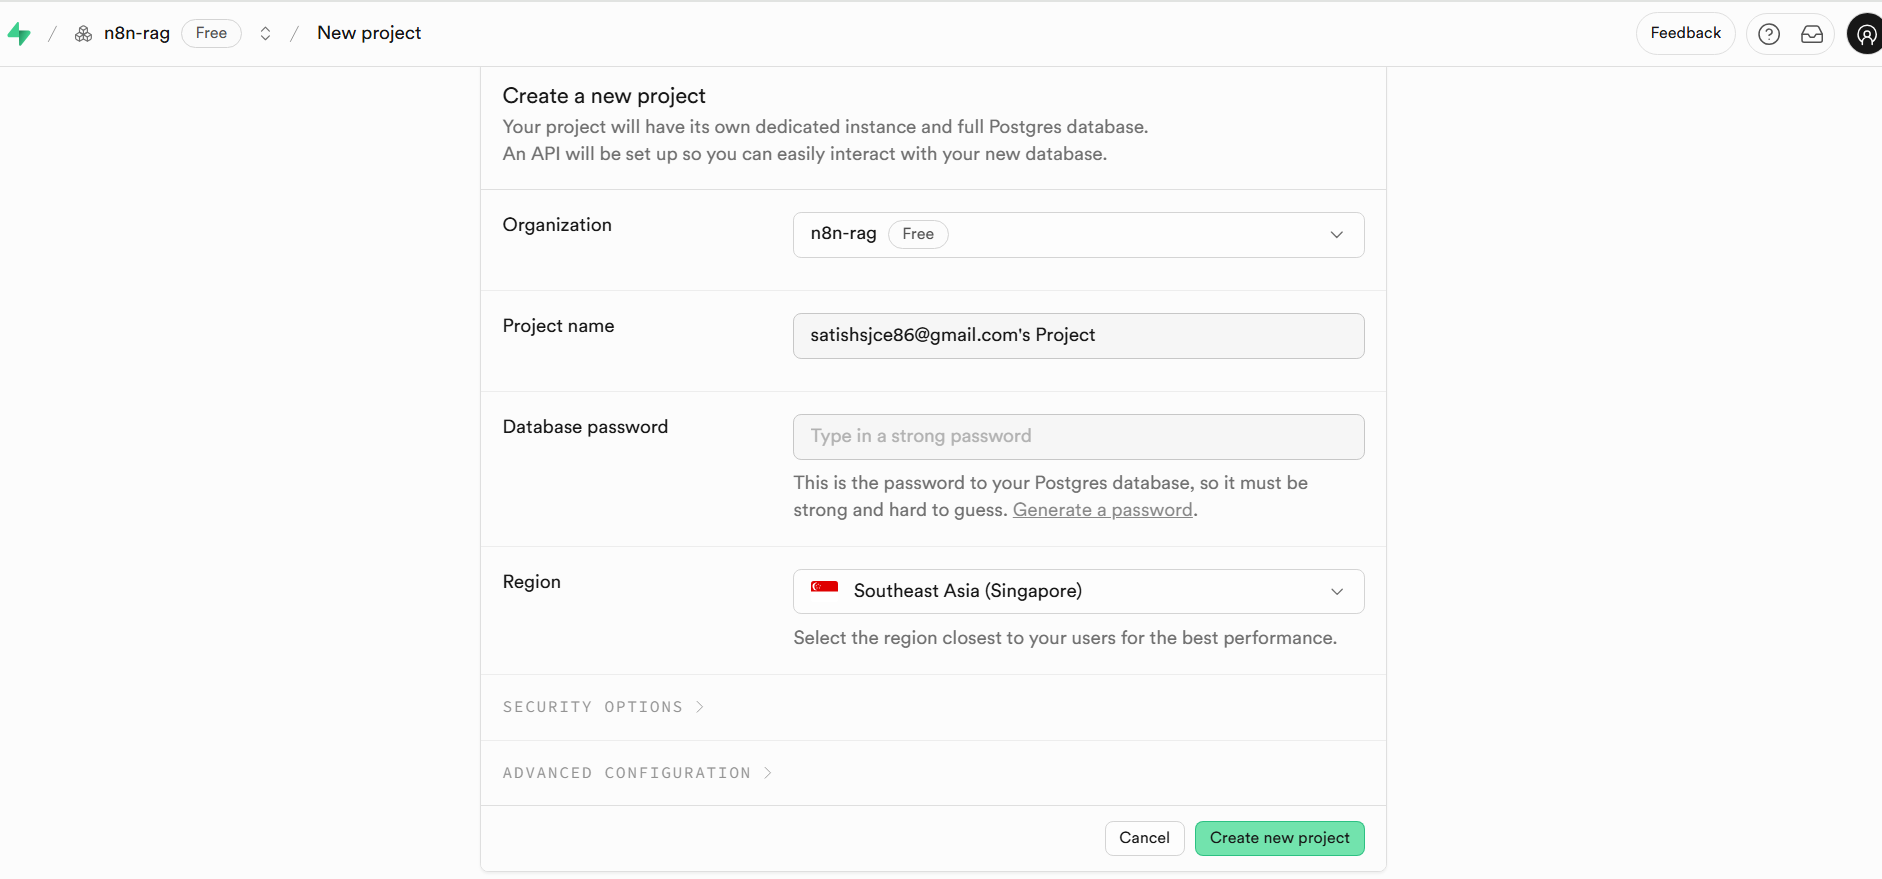 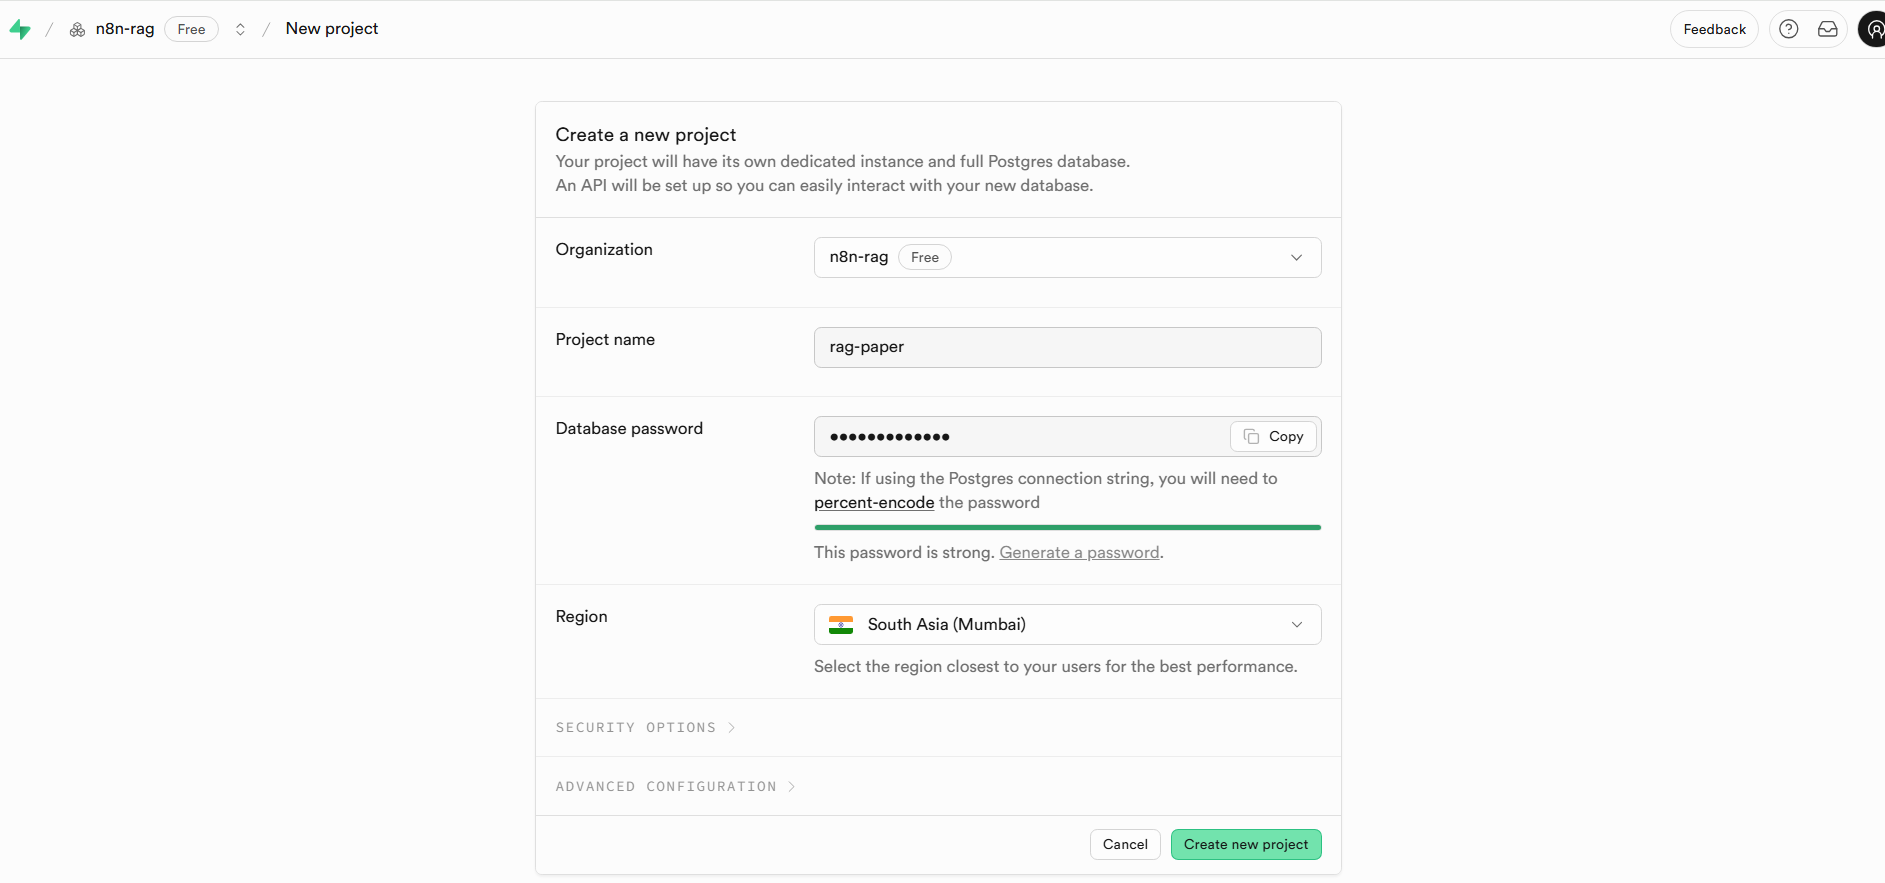 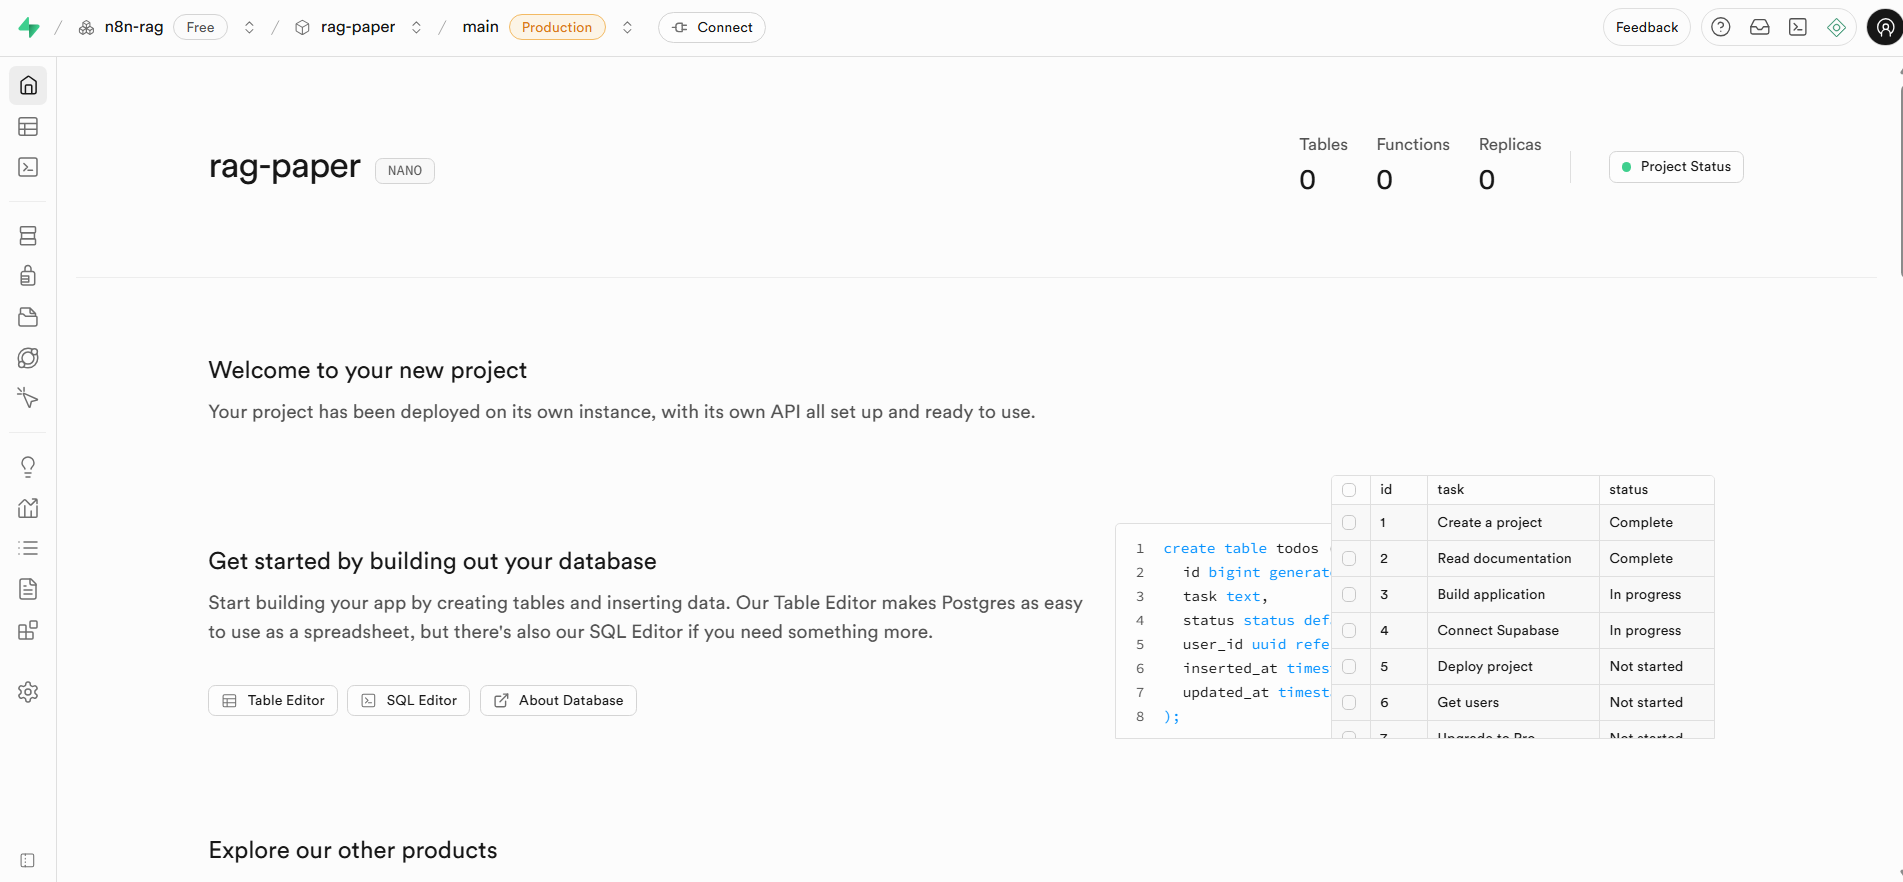

`Dark Mode`

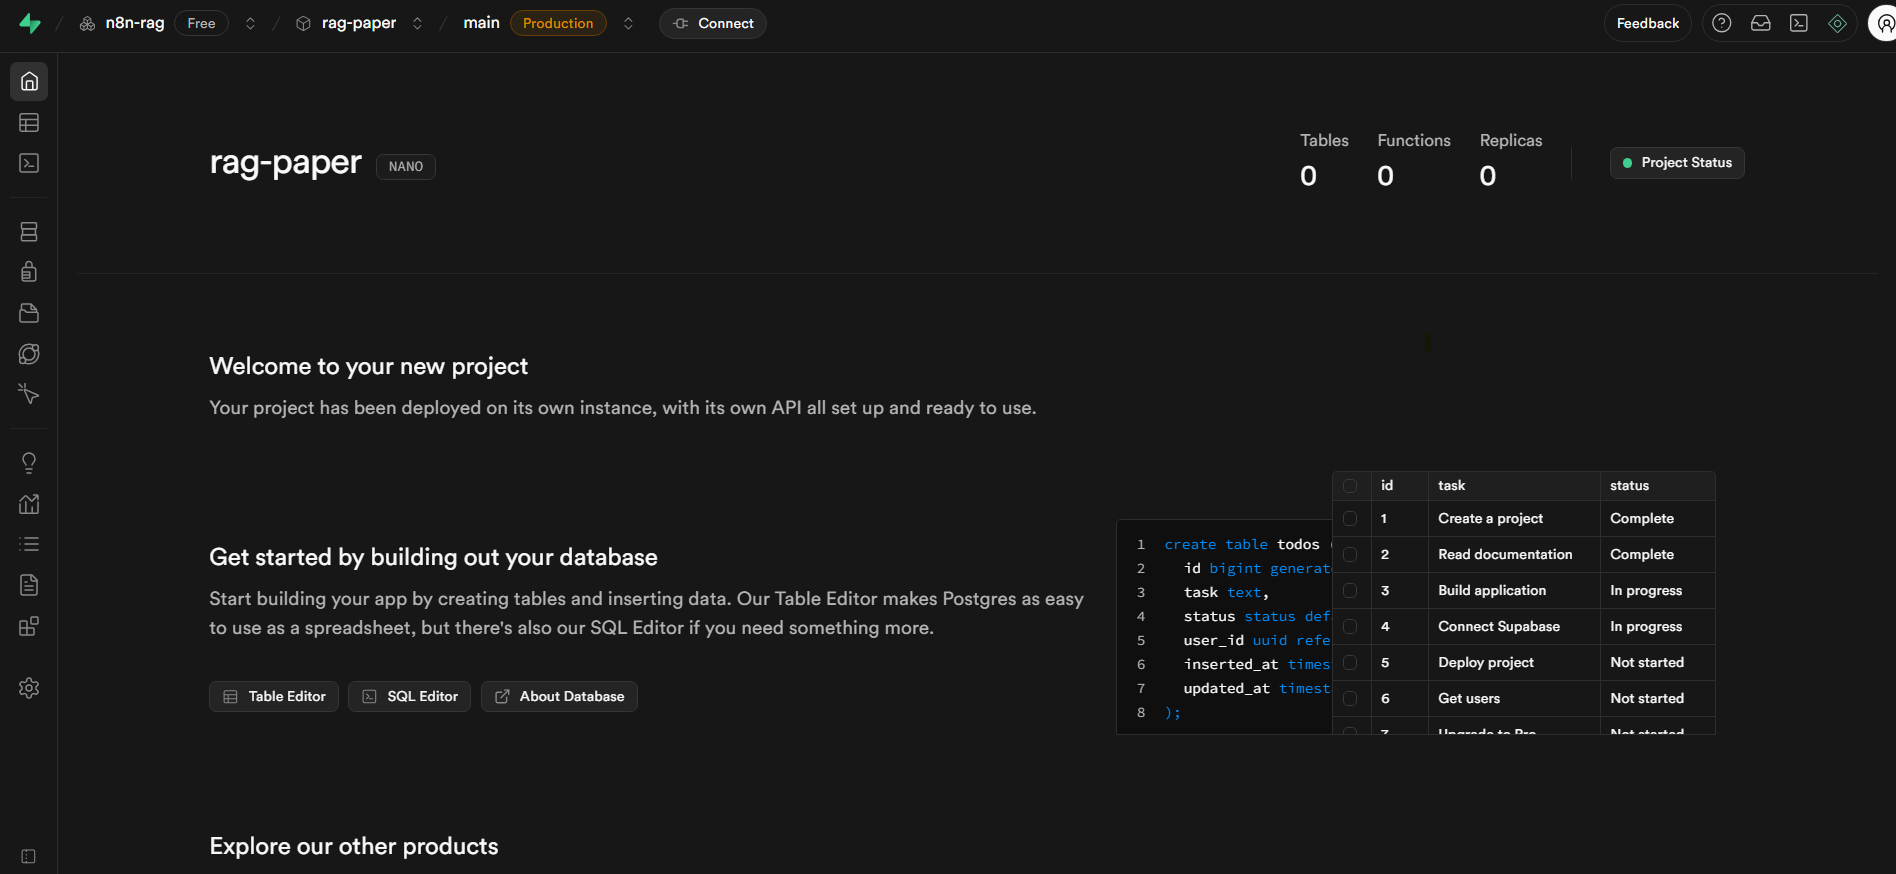

<hr>

`Organization`

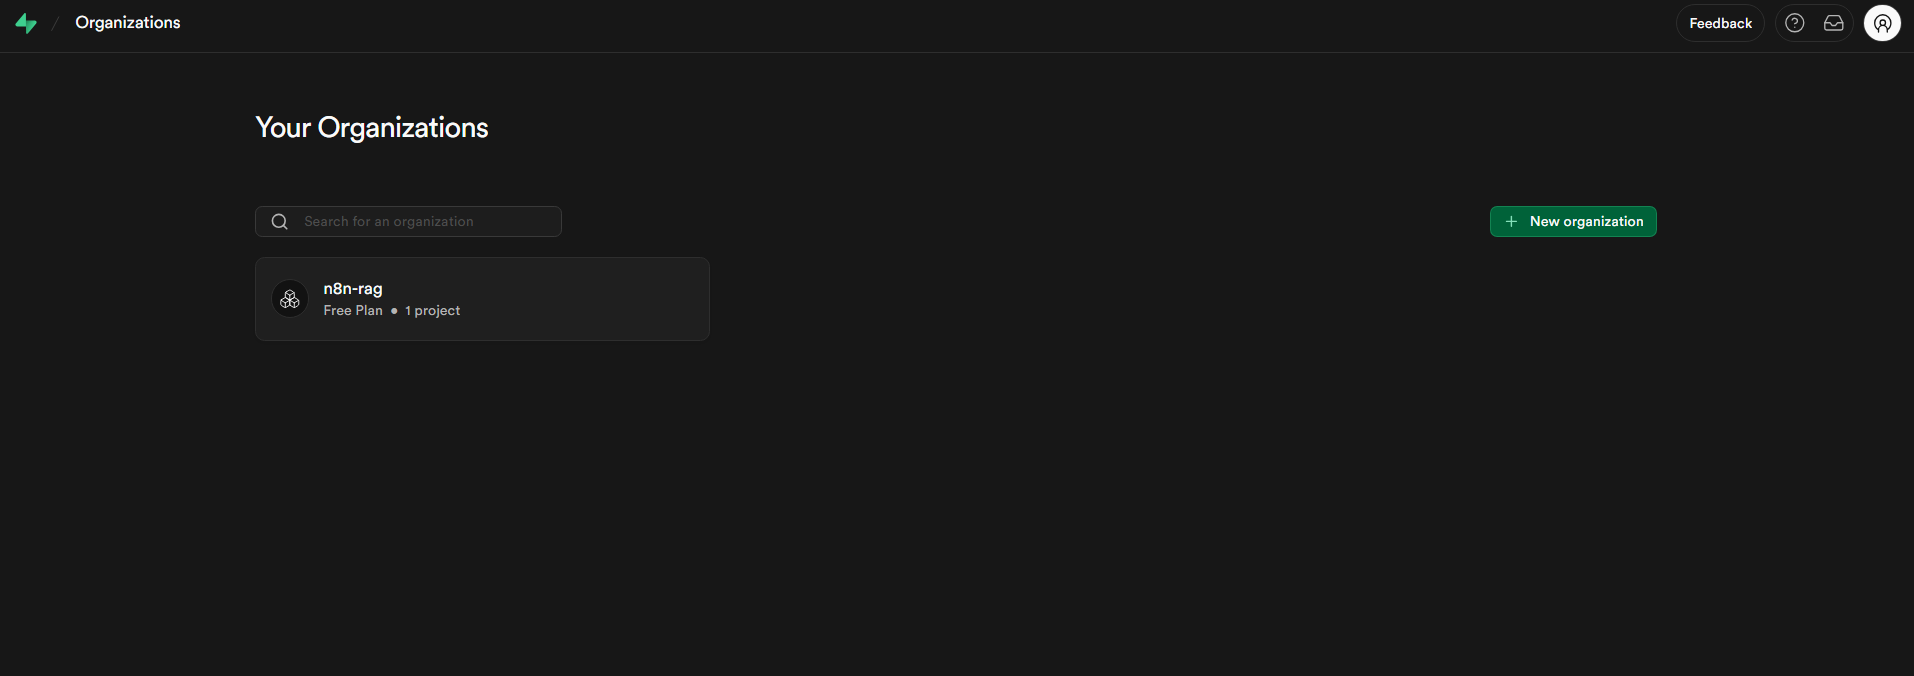

`Projects`

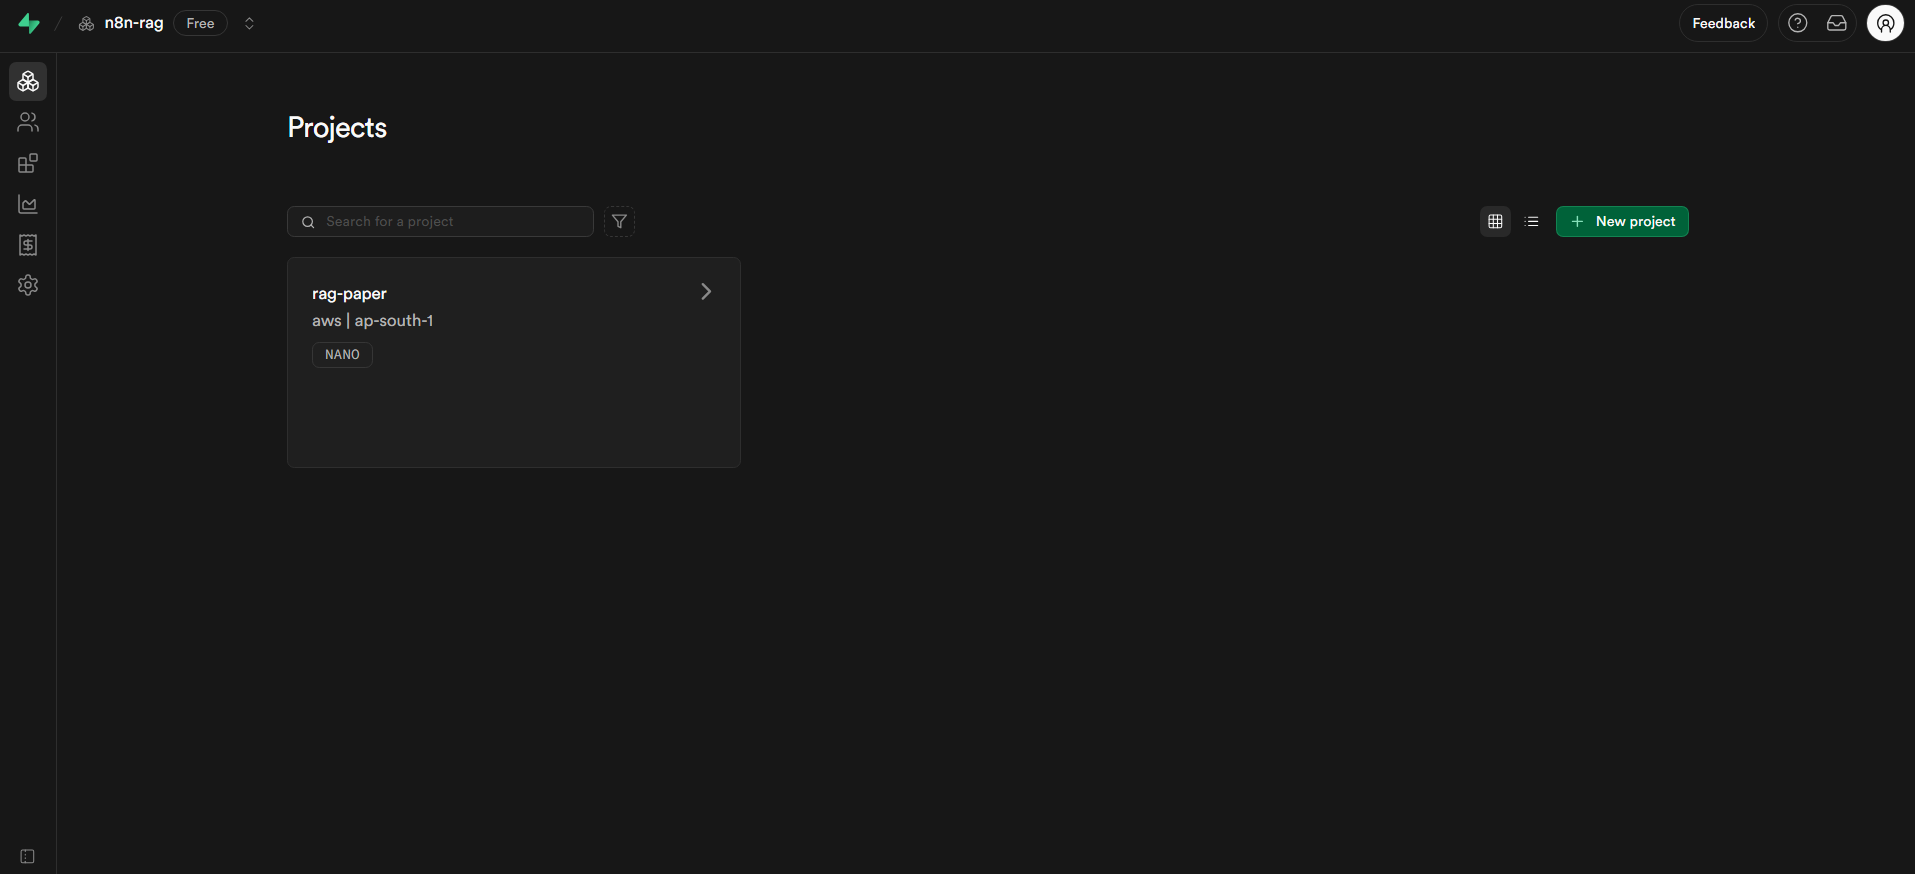

`Project -> rag-paper`

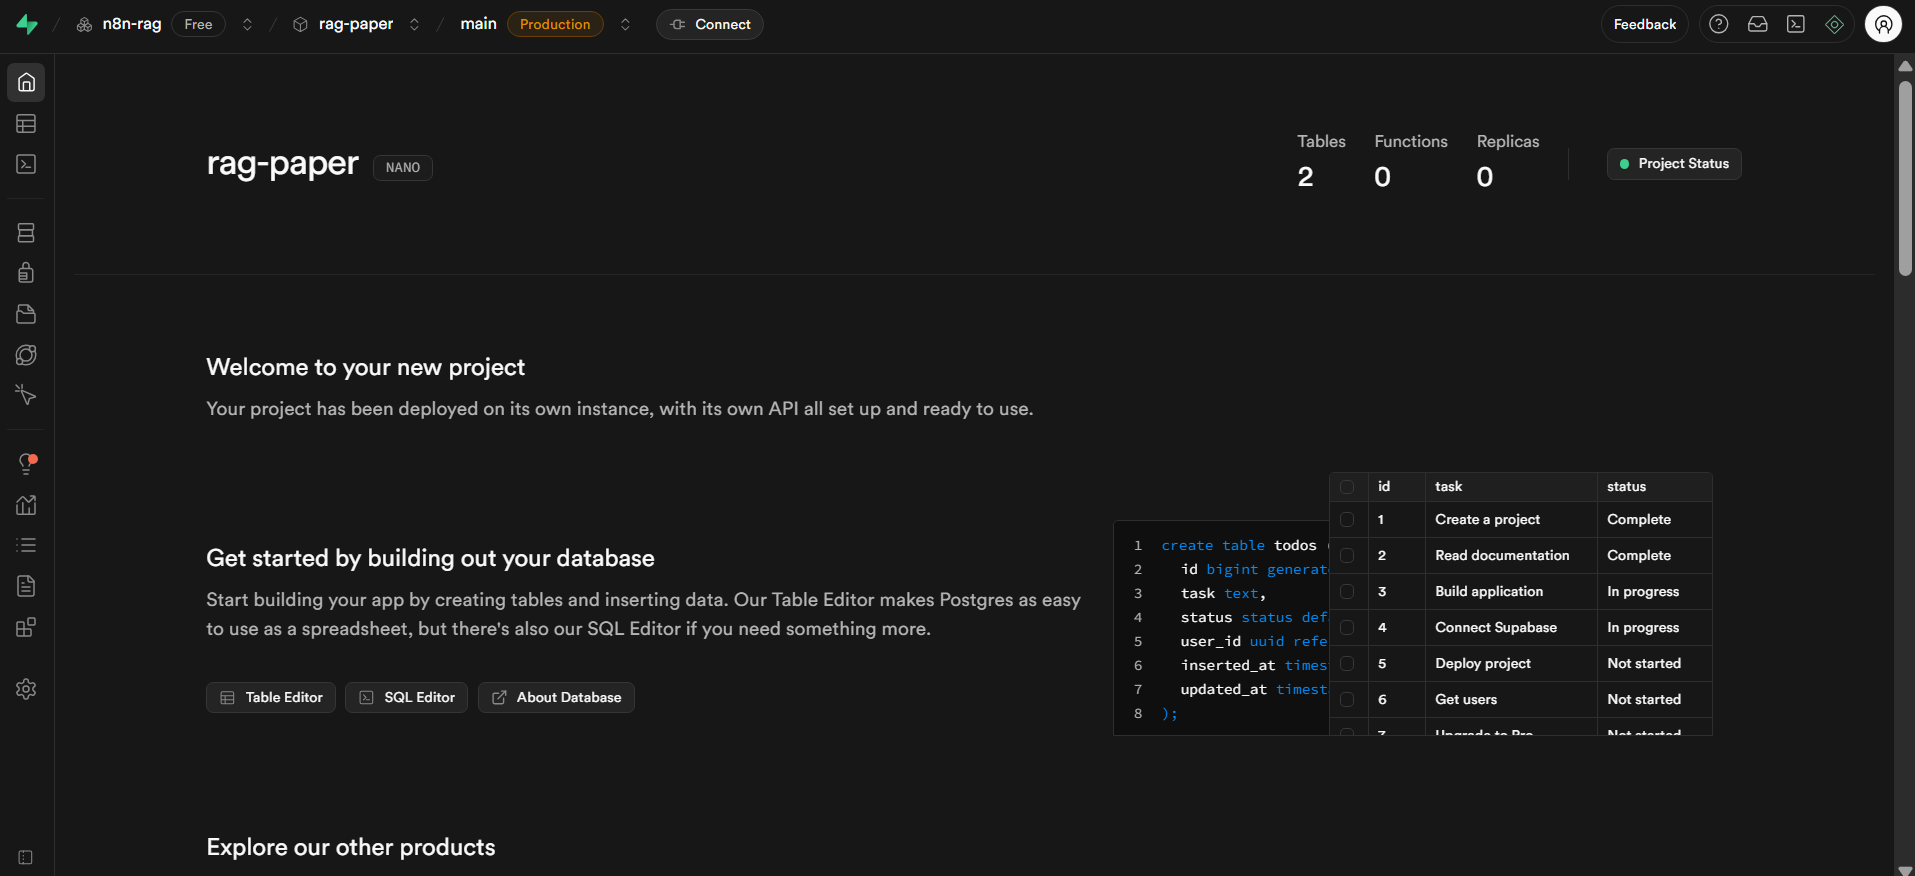

`Table Editor -> documents -> 53 records`

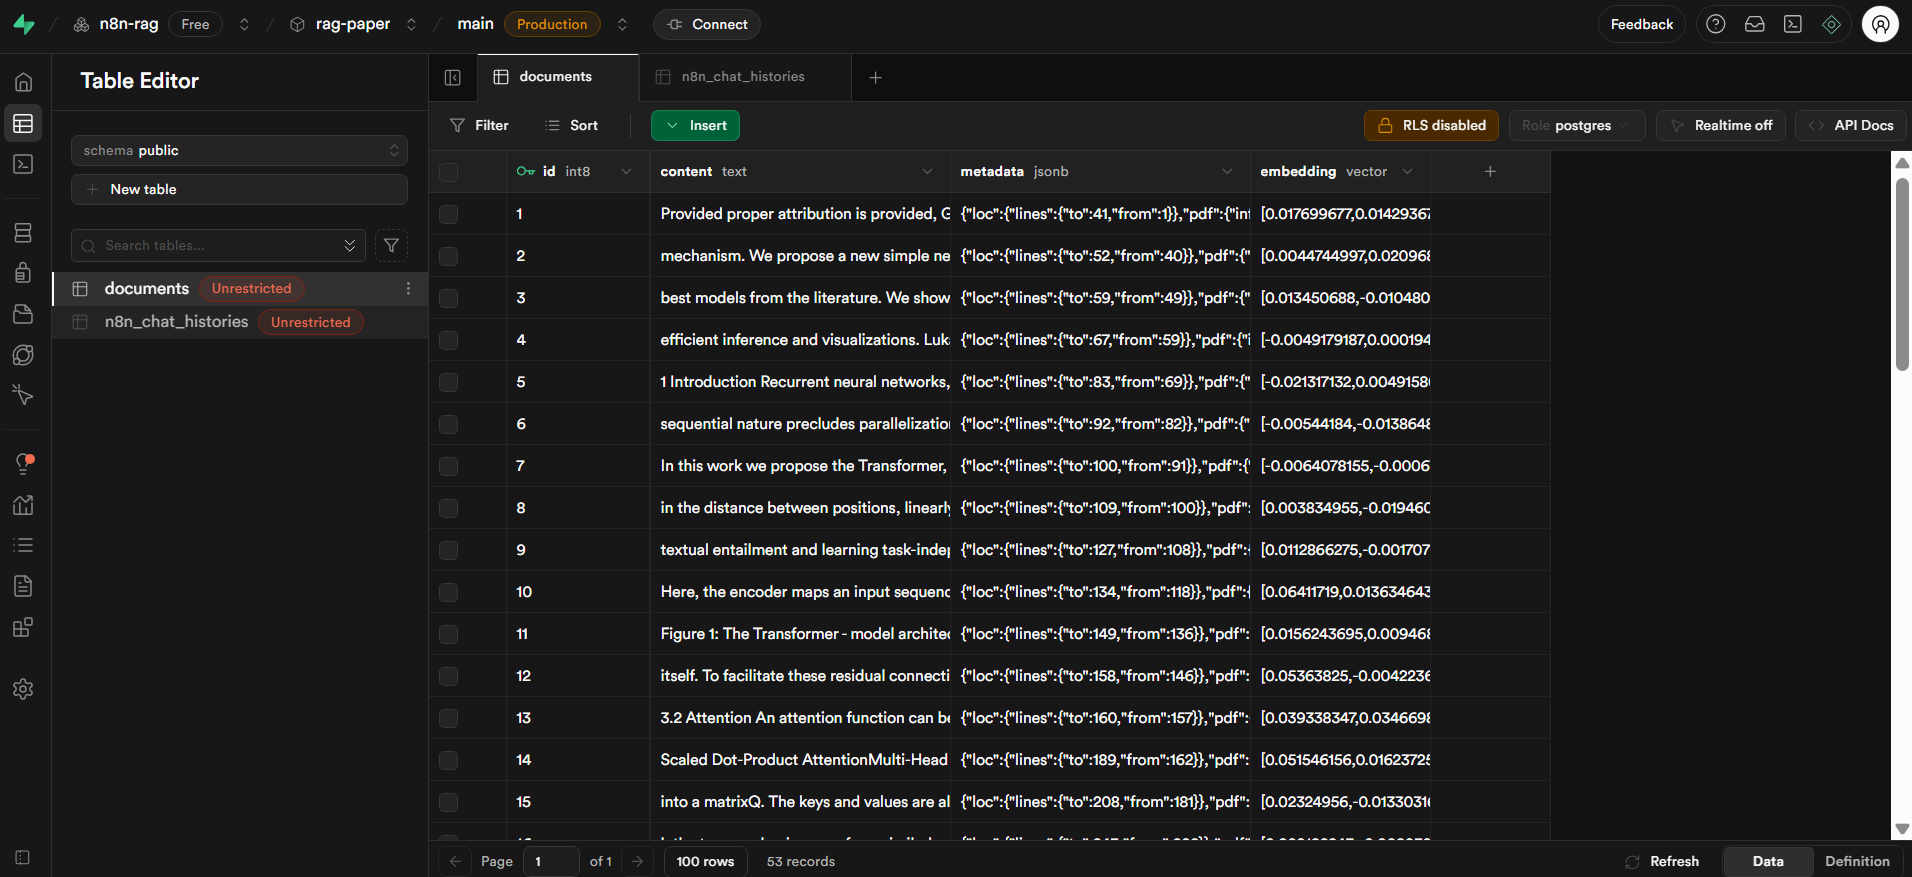 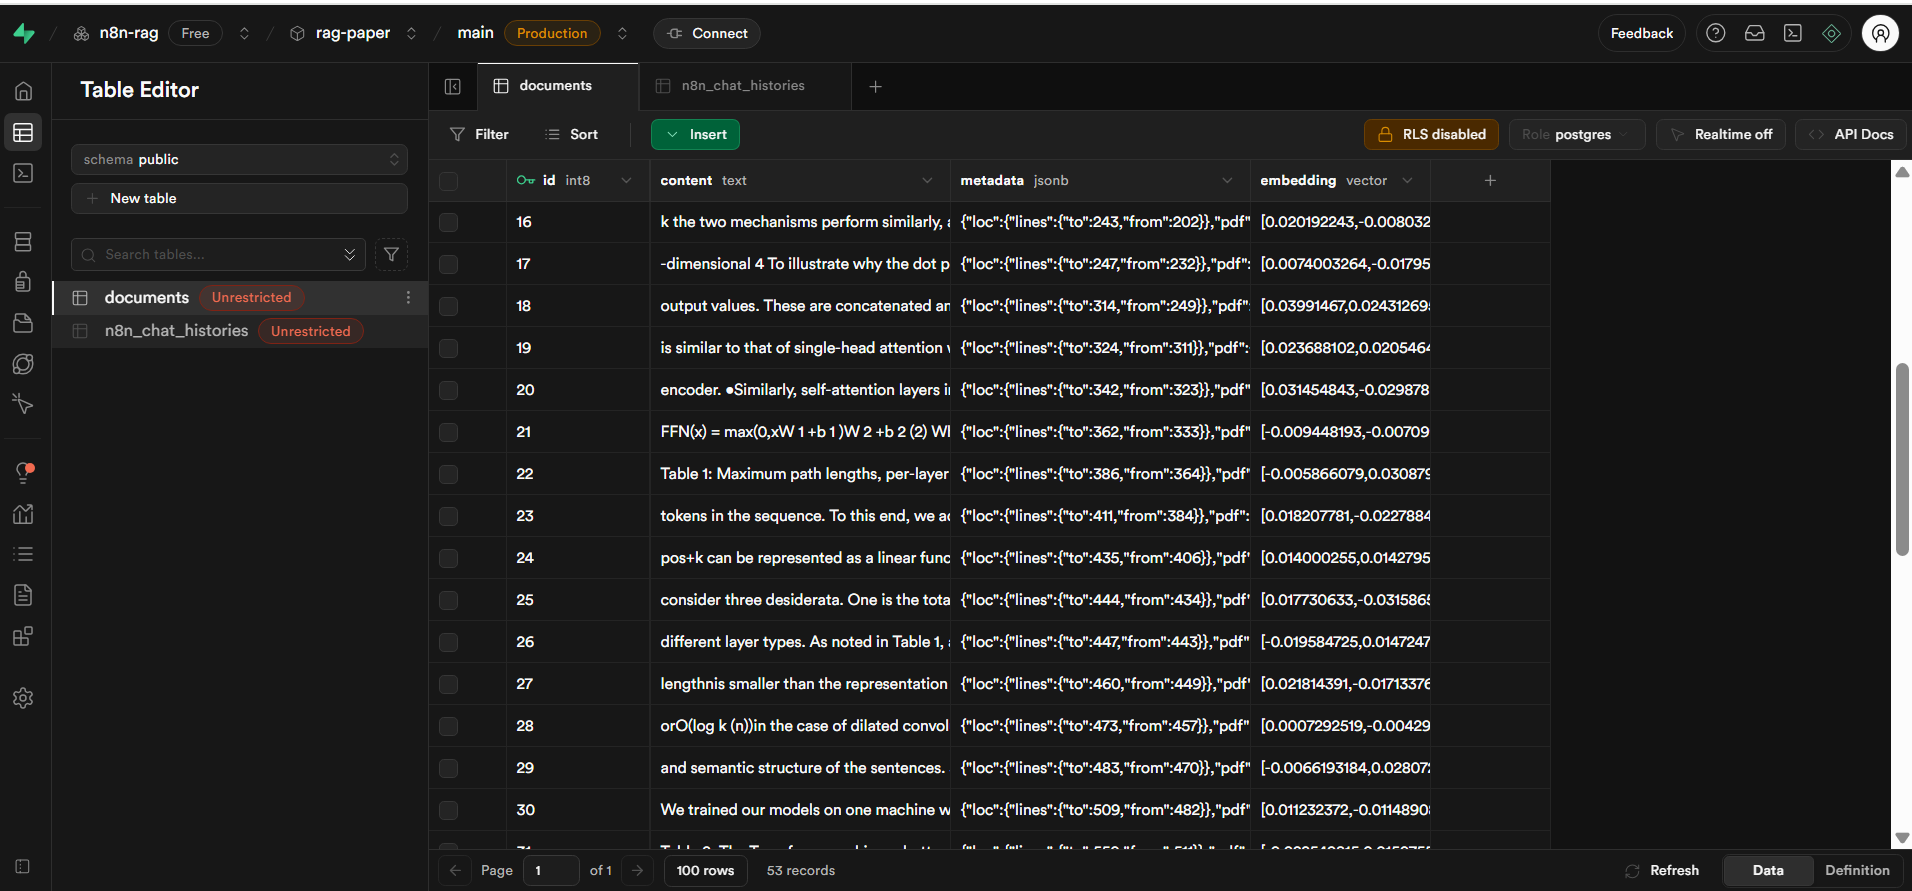 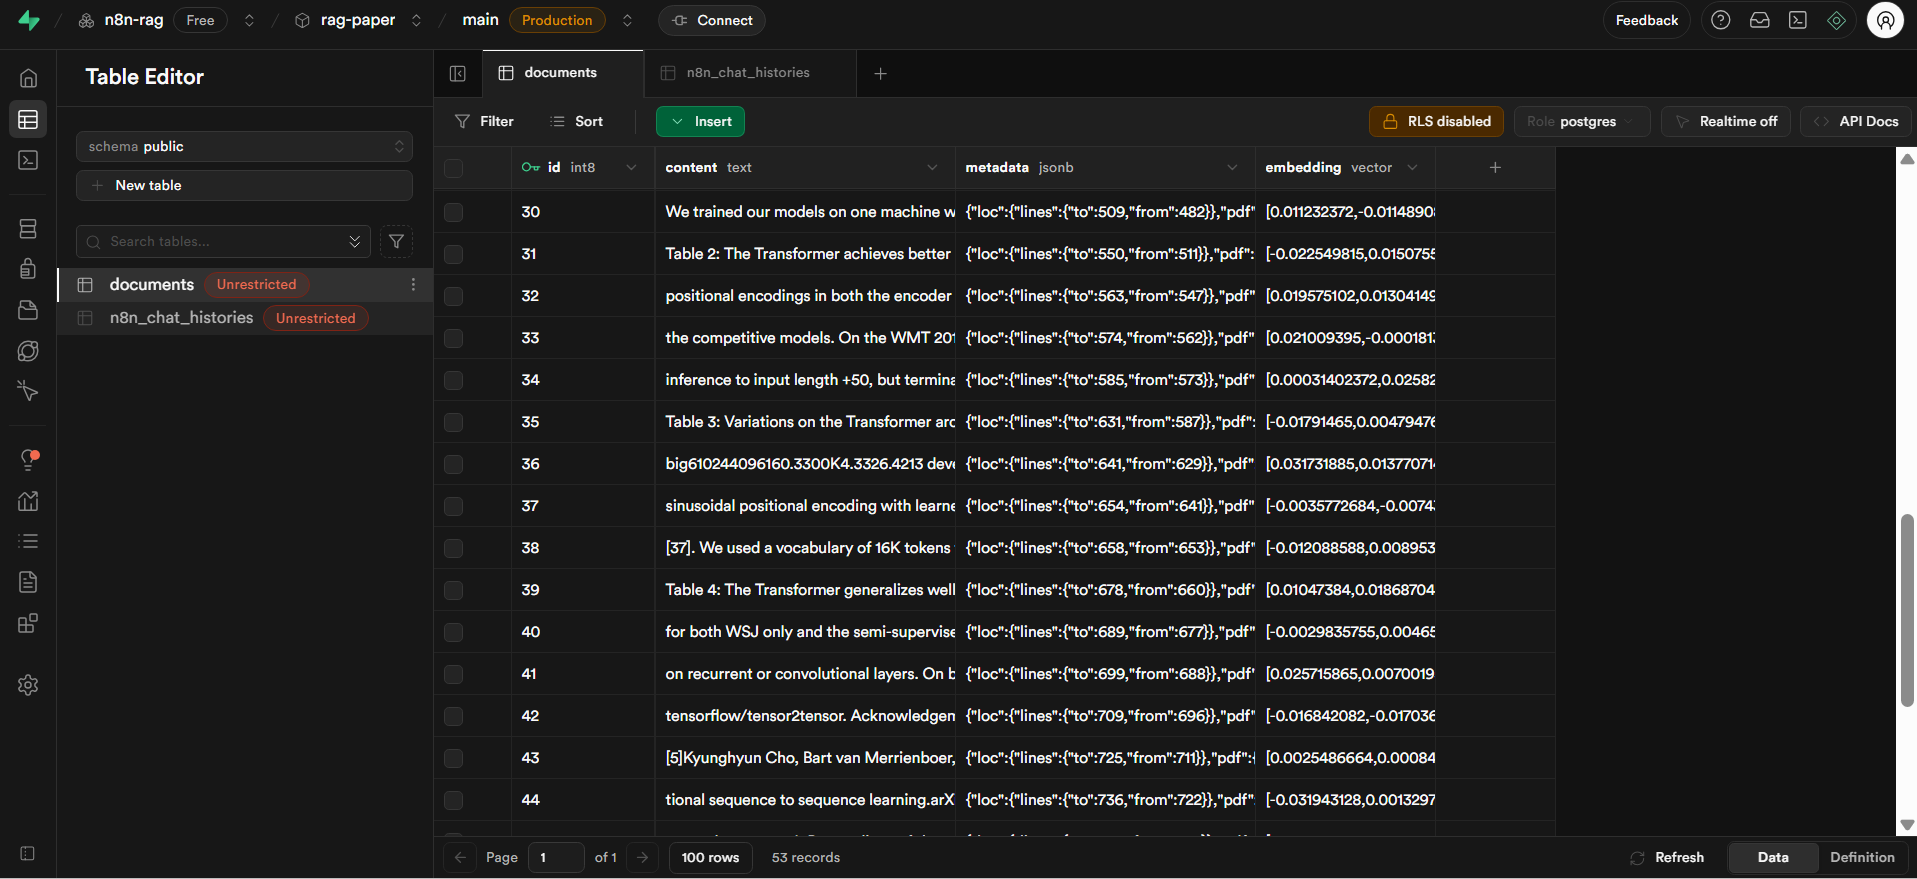 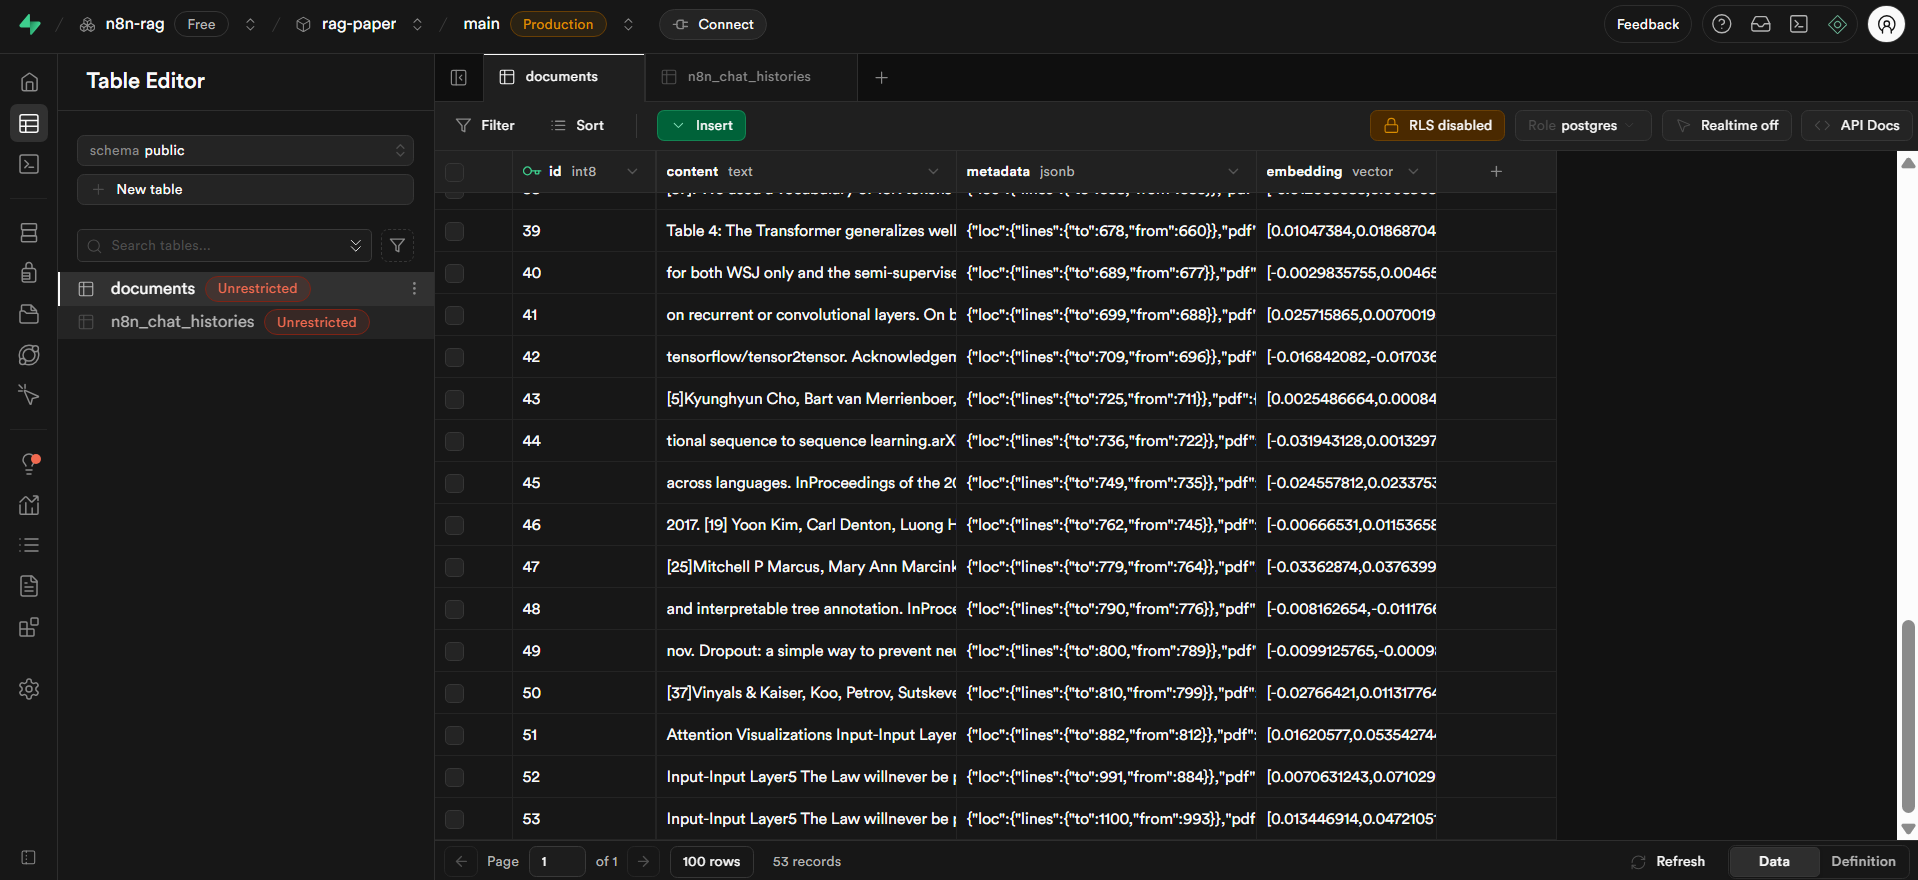

`Table Editor -> n8n_chat_histories`

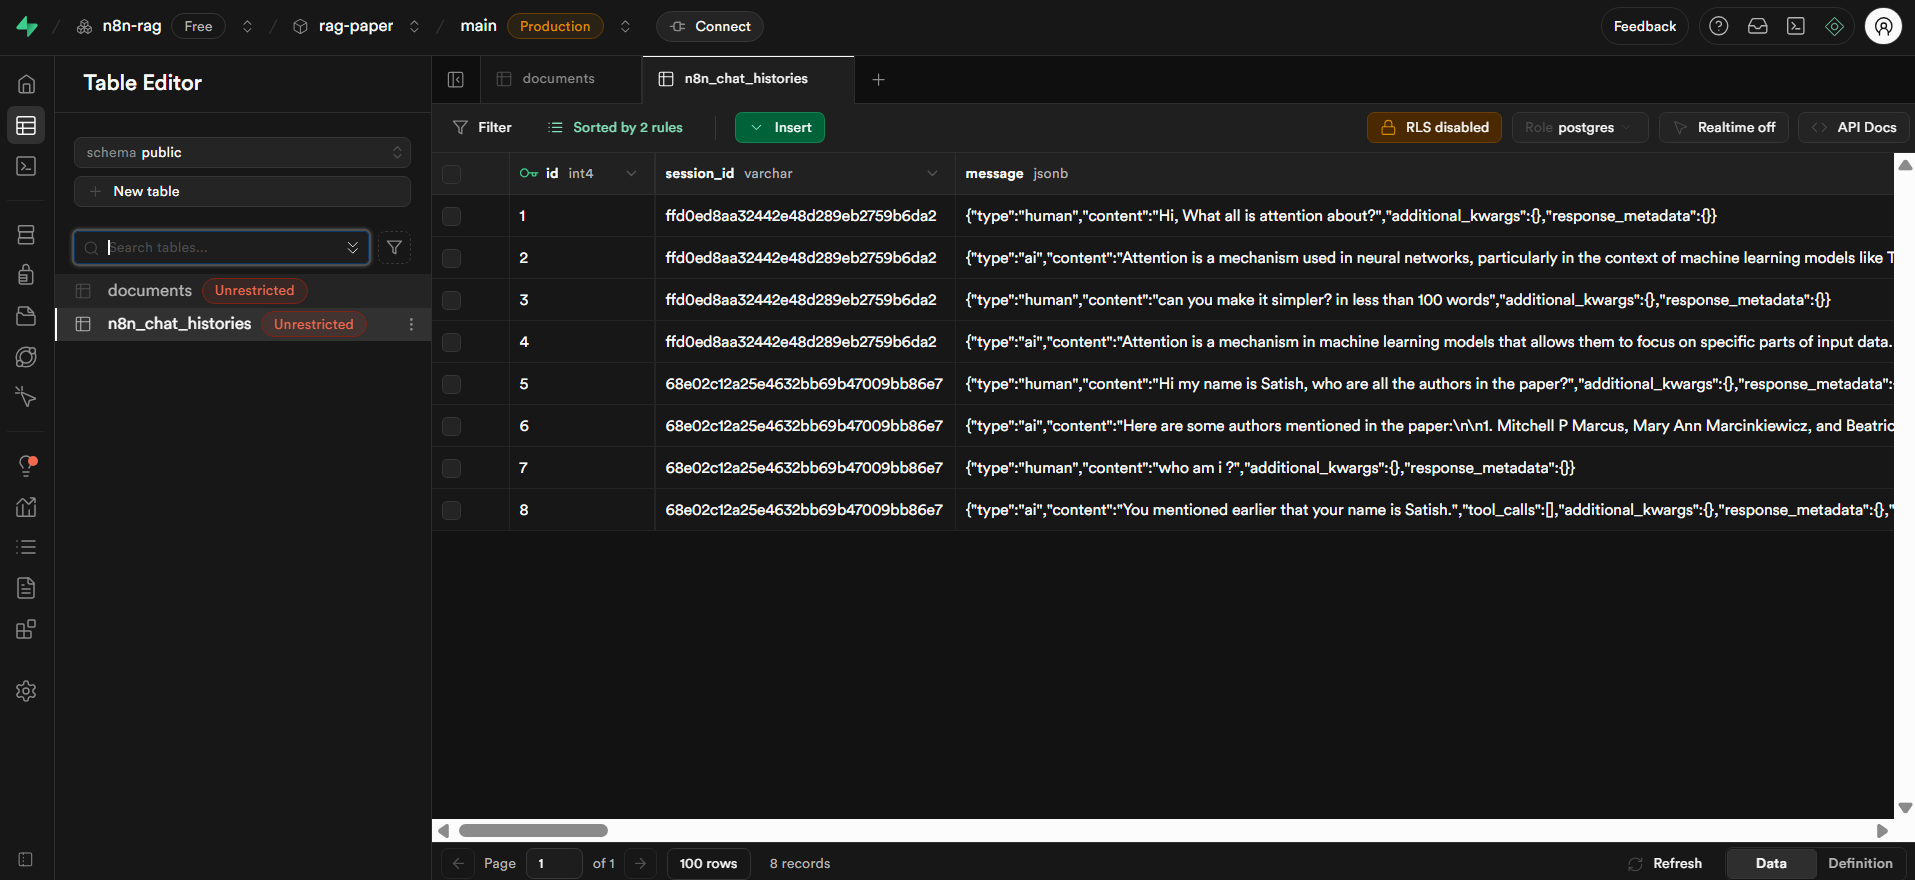

`SQL Editor -> Vector Document Search System`

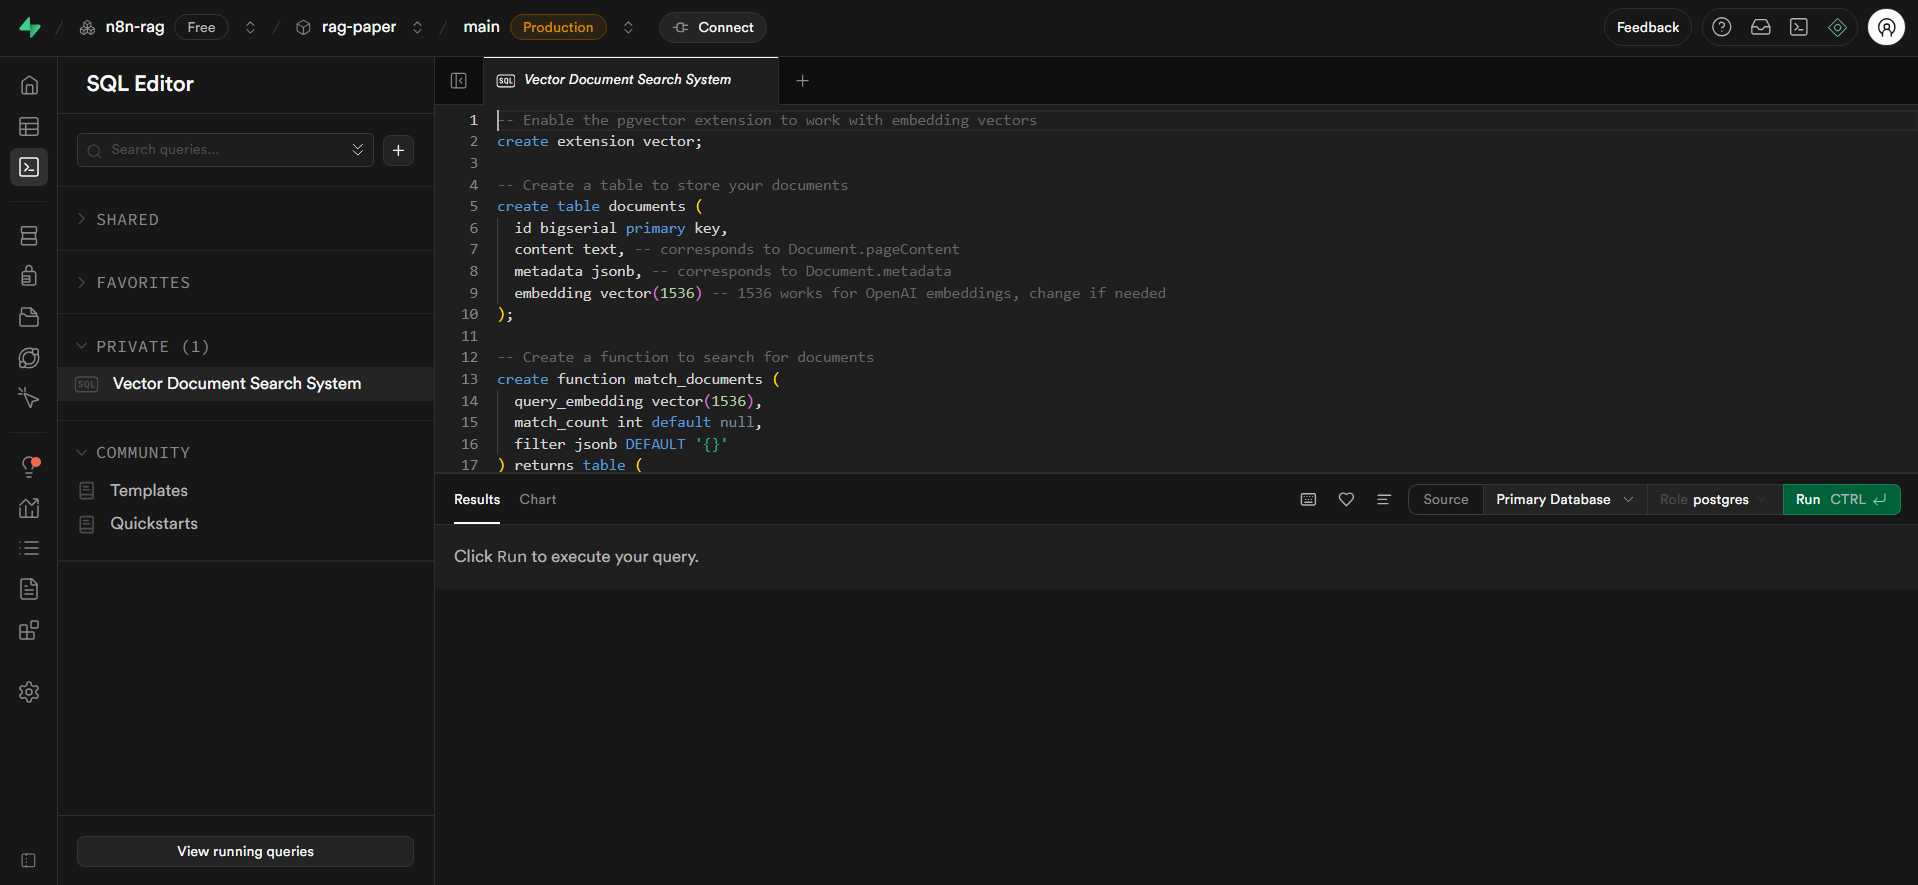

Supabase provides a [quickstart for setting up your vector store](https://supabase.com/docs/guides/ai/langchain?database-method=sql). If you use settings other than the defaults in the quickstart, this may affect parameter settings in n8n. Make sure you understand what you're doing.

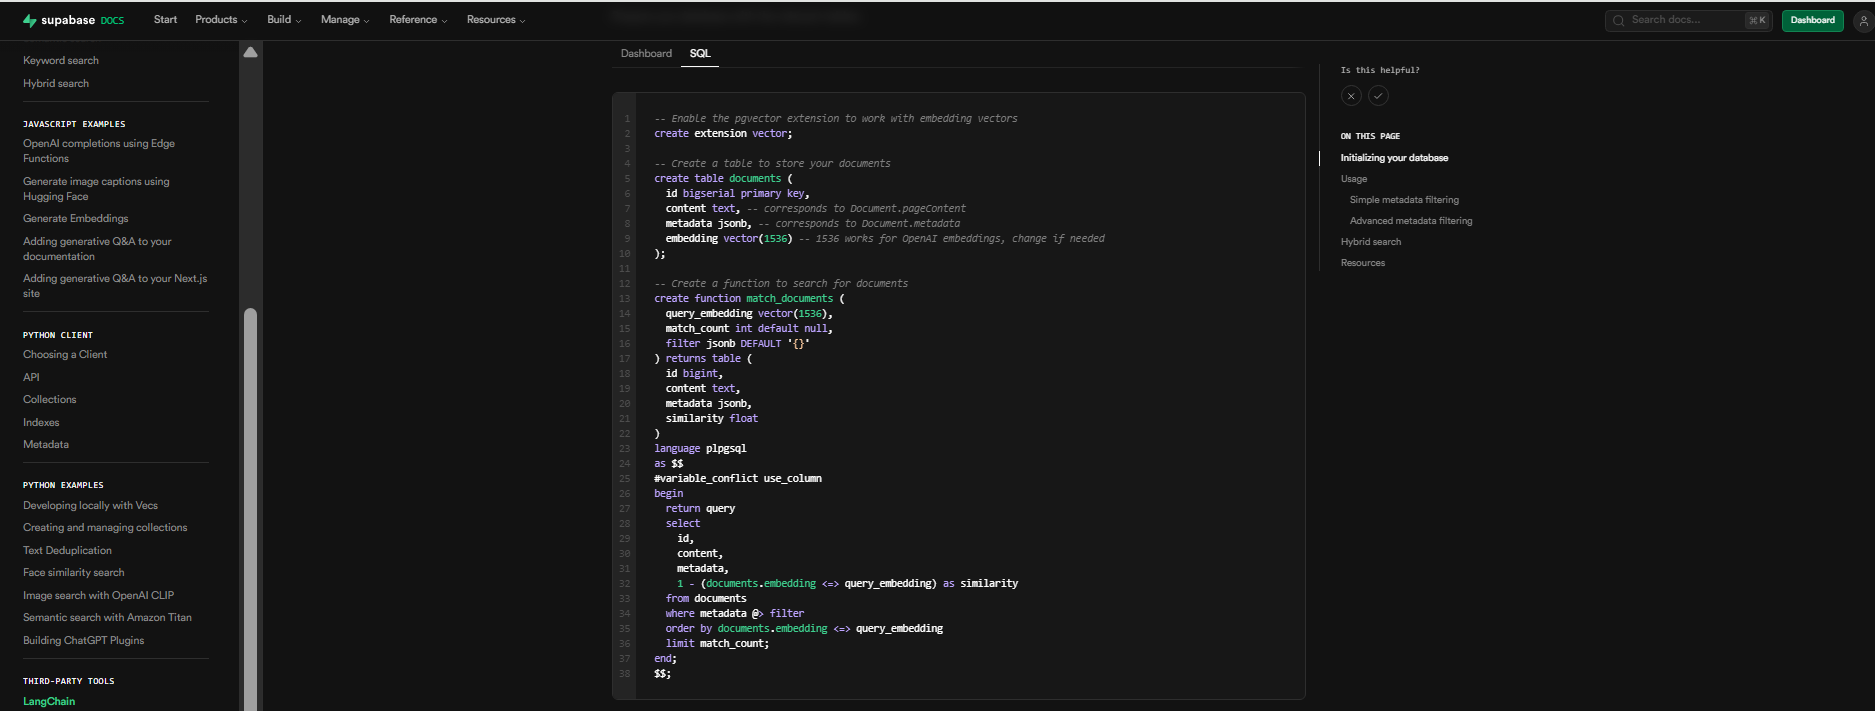 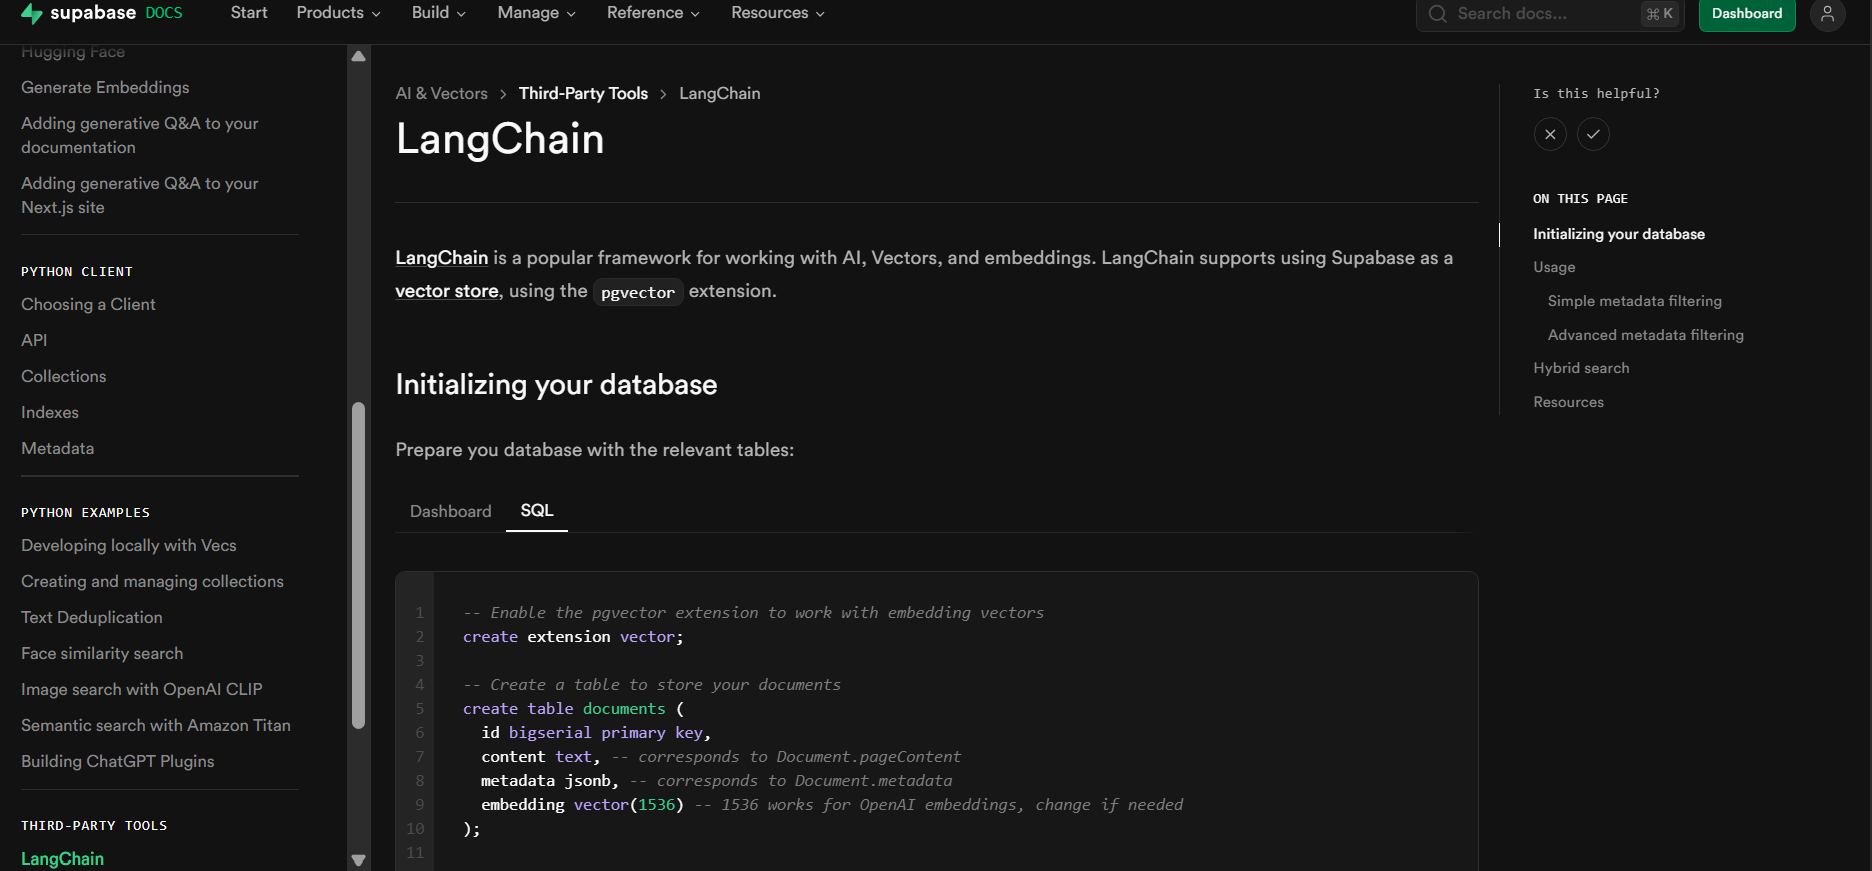 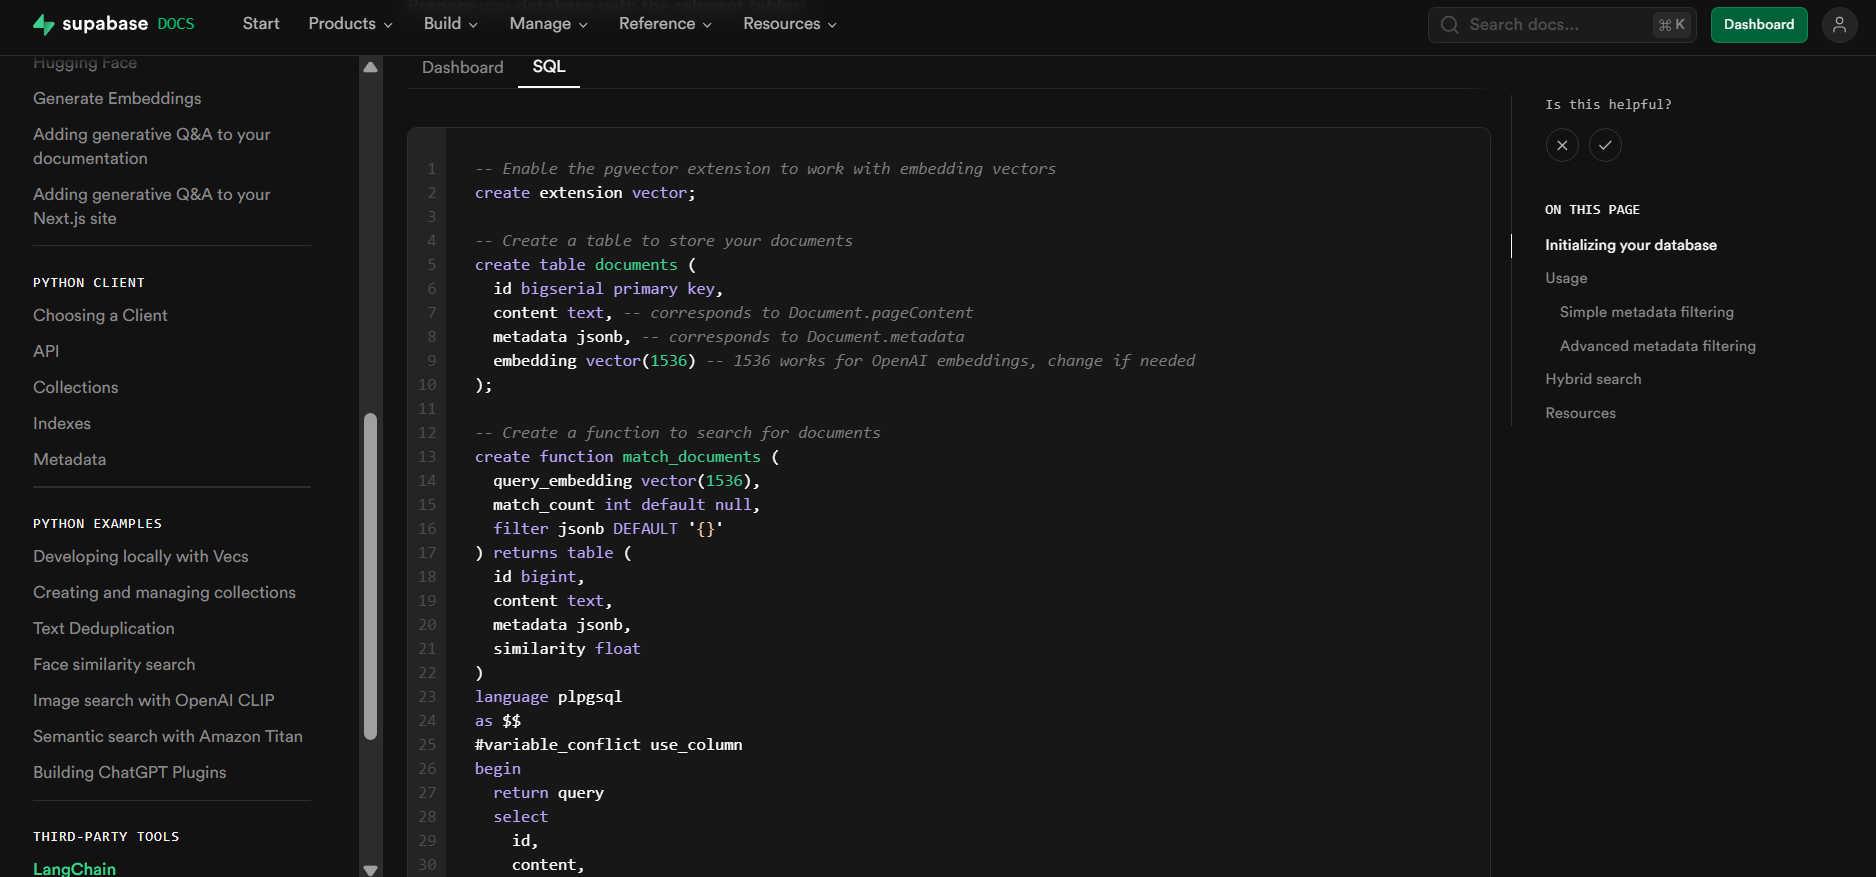 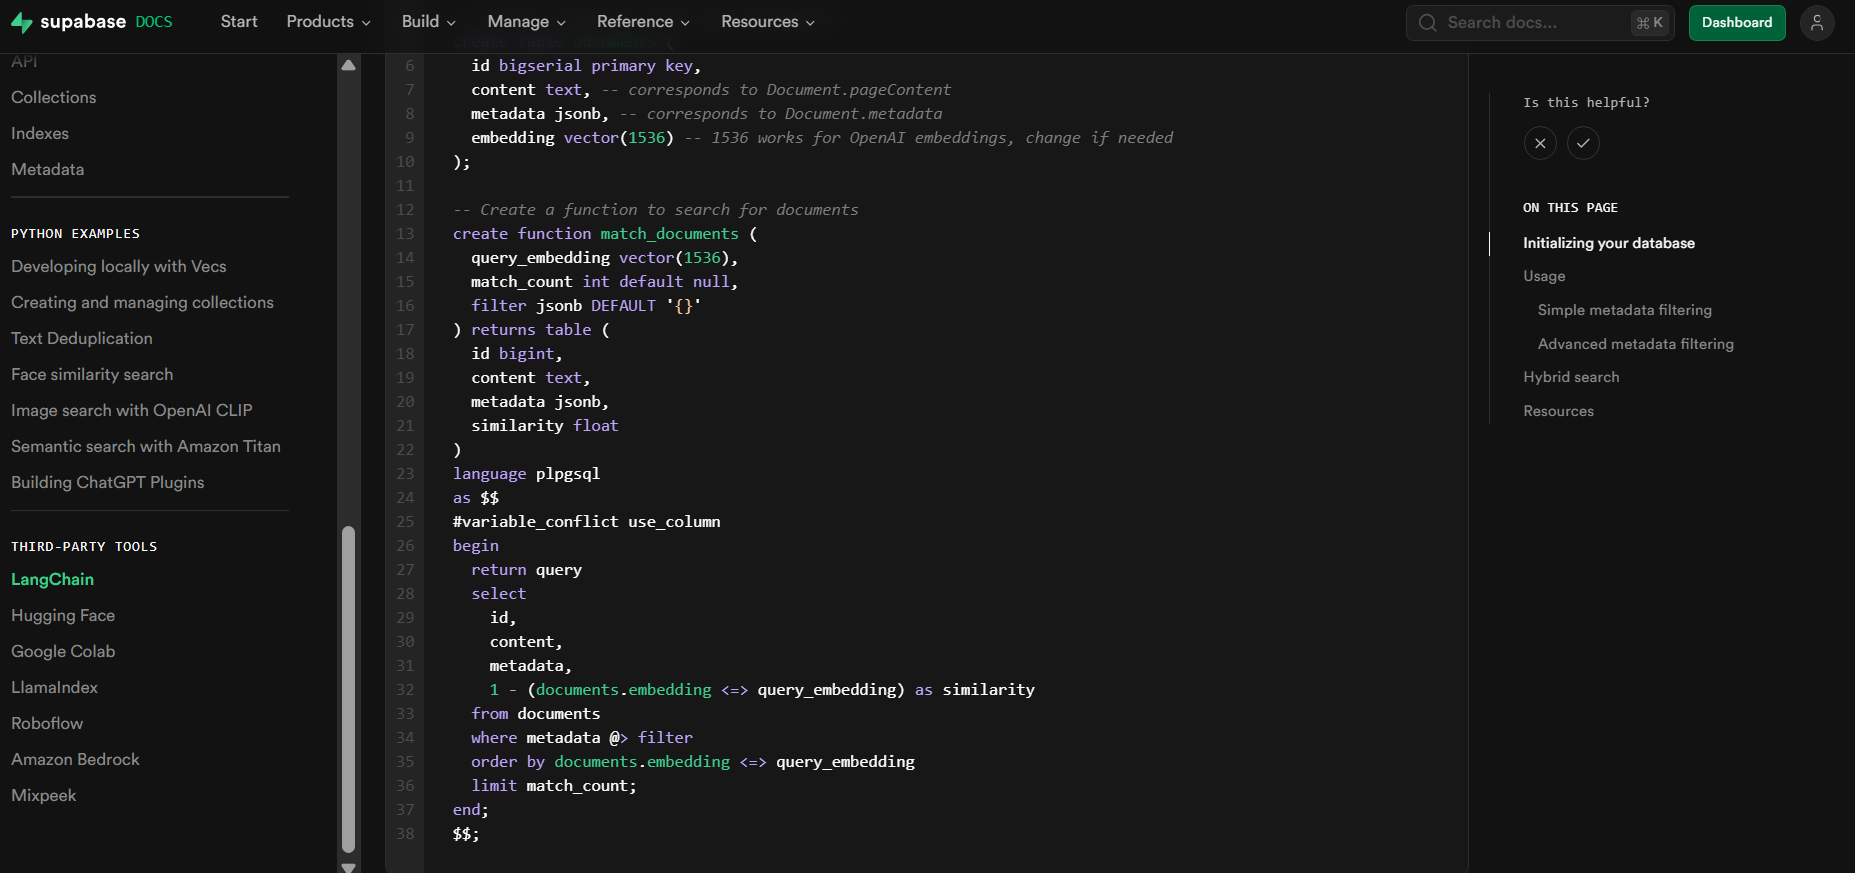

```Sql
-- Enable the pgvector extension to work with embedding vectors
create extension vector;

-- Create a table to store your documents
create table documents (
  id bigserial primary key,
  content text, -- corresponds to Document.pageContent
  metadata jsonb, -- corresponds to Document.metadata
  embedding vector(1536) -- 1536 works for OpenAI embeddings, change if needed
);

-- Create a function to search for documents
create function match_documents (
  query_embedding vector(1536),
  match_count int default null,
  filter jsonb DEFAULT '{}'
) returns table (
  id bigint,
  content text,
  metadata jsonb,
  similarity float
)
language plpgsql
as $$
#variable_conflict use_column
begin
  return query
  select
    id,
    content,
    metadata,
    1 - (documents.embedding <=> query_embedding) as similarity
  from documents
  where metadata @> filter
  order by documents.embedding <=> query_embedding
  limit match_count;
end;
$$;
```

